# 13. SVR Augmented Reality Virtual Try-on Survey Data Analysis

In [64]:
from datetime import datetime

# Get the current date and time
current_time = datetime.now()

print(f"Current date and time: {current_time}")

Current date and time: 2024-10-24 15:02:49.280819


### Change Log

In [65]:
from datetime import datetime

# Get the current date and time
current_time = datetime.now()

print(f"Current date and time: {current_time}")

import pandas as pd
import numpy as np
from numpy import arange
import scipy.stats as stats
from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, r2_score
# Load libraries
import numpy
from numpy import arange
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import semopy
from semopy import Model, Optimizer, calc_stats
#from pdpbox import pdp, get_dataset, info_plots
from sklearn.metrics import mutual_info_score
from sklearn import metrics
#import eli5
#from eli5.sklearn import PermutationImportance

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mutual_info_score
from sklearn.datasets import make_regression
from sklearn.pipeline import Pipeline
 
# Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.cluster import KMeans

# Feature Selection and Dimensionality Reduction
from sklearn.decomposition import PCA
#from eli5.sklearn import PermutationImportance

# Statistical Analysis
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
from factor_analyzer import FactorAnalyzer
import semopy
from semopy import Model, Optimizer, calc_stats

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import pyplot
from pandas.plotting import scatter_matrix

#Model Interpretation
#import eli5

# Language Translation
from googletrans import Translator
translator = Translator()
from translate import Translator

translator = Translator(to_lang="en", from_lang="vi")
translation_1 = translator.translate("nữ")
translation_0 = translator.translate("nam")

print(f"Translation of 'nữ': {translation_1}")
print(f"Translation of 'nam': {translation_0}")

# Miscellaneous
# Set display options to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

Current date and time: 2024-10-24 15:02:49.332294
Translation of 'nữ': female
Translation of 'nam': male


### Data Acquisition

In [66]:
#read csv file

df_survey_cleaned = pd.read_csv(r'C:\Users\cemcd\OneDrive\Documents\NCU\Dissertation\DisserationDataFilesInfo\df_suvey_cleaned.csv')

In [67]:
#display column headers and the first row

df_survey_cleaned.head(2)

,Unnamed: 0,Timestamp,AR_Knowledgeable,familiar_with_technology,use_AR_everyday,use_in_all_aspects,Virtual_shopping_environment,Virtual_tour,Visualize_model,Emulation,PE1,PE2,PE3,PE4,SOI1,SOI2,SOI3,SOI4,SEI1,SEI2,SEI3,PEOU1,PEOU2,PEOU3,PU1,PU2,PU3,PU4,B1,AT1,AT2,AT3,PPV1,PPV2,PPV3,HM1,HM2,HM3,BI1,BI2,BI3,BI4,Gender,AGE,Location,Gender_eng,Gender_vietnamese,Gender_num,AGE_eng,AGE_num,Age_vietnamese,Usage_1,Usage_2,Usage_3,Usage_4,Usage_5,Usage_6,Usage_7,Usage_1_en,Usage_2_en,Usage_3_en,Usage_4_en,Usage_5_en,Usage_6_en,Usage_7_en,use_type_cnts,BI,PE,SOI,SEI,HM,AT,PPV,PU,PEOU,PE_centered,SOI_centered,SEI_centered,HM_centered,AT_centered,PPV_centered,PU_centered,PEOU_centered,AR_Knowledgeable_centered,familiar_with_technology_centered,use_AR_everyday_centered,Virtual_shopping_environment_centered,Virtual_tour_centered,Visualize_model_centered,Emulation_centered,AGEGender_centered,AGEAR_Knowledgeable,AGEfamiliar_with_technology,AGEuse_AR_everyday,AGEVirtual_shopping_environment,AGEVirtual_tour,AGEVisualize_model,AGEEmulation,GenderAR_Knowledgeable,Genderfamiliar_with_technology,Genderuse_AR_everyday,GenderVirtual_shopping_environment,GenderVirtual_tour,GenderVisualize_model,GenderEmulation,GenderPU_centered,GenderPE_centered,GenderPEOU_centered,GenderAT_centered,GenderPPV_centered,GenderHM_centered,GenderSOI_centered,GenderSEI_centered,AGEPEOU_centered,AGEPU_centered,AGESOI_centered,AGESEI_centered,AGEPPV_centered,AGEHM_centered,AGEPE_centered,AGEAT_centered,PEAT_centered,HMAT_centered,HMPU_centered,HMPEOU_centered,HMSOI_centered,HMSEI_centered,HMPE_centered,HMPPV_centered,SOIPU_centered,SEIPU_centered,SOIPEOU_centered,SEIPEOU_centered,target_variable_num,target_variable_cat,PE_centered_squared,PE_centered_cubed,SOI_centered_squared,SOI_centered_cubed,SEI_centered_squared,SEI_centered_cubed,HM_centered_squared,HM_centered_cubed,AT_centered_squared,AT_centered_cubed,PPV_centered_squared,PPV_centered_cubed,PU_centered_squared,PU_centered_cubed,PEOU_centered_squared,PEOU_centered_cubed,AGEGender_centered_squared,AGEGender_centered_cubed,GenderPU_centered_squared,GenderPU_centered_cubed,GenderPEOU_centered_squared,GenderPEOU_centered_cubed,GenderAT_centered_squared,GenderAT_centered_cubed,GenderPPV_centered_squared,GenderPPV_centered_cubed,GenderPE_centered_squared,GenderPE_centered_cubed,GenderHM_centered_squared,GenderHM_centered_cubed,GenderSOI_centered_squared,GenderSOI_centered_cubed,GenderSEI_centered_squared,GenderSEI_centered_cubed,AGEPEOU_centered_squared,AGEPEOU_centered_cubed,AGEPU_centered_squared,AGEPU_centered_cubed,AGESOI_centered_squared,AGESOI_centered_cubed,AGESEI_centered_squared,AGESEI_centered_cubed,AGEPPV_centered_squared,AGEPPV_centered_cubed,AGEHM_centered_squared,AGEHM_centered_cubed,AGEPE_centered_squared,AGEPE_centered_cubed,AGEAT_centered_squared,AGEAT_centered_cubed,PEAT_centered_squared,PEAT_centered_cubed,HMAT_centered_squared,HMAT_centered_cubed,HMPU_centered_squared,HMPU_centered_cubed,HMPEOU_centered_squared,HMPEOU_centered_cubed,HMSOI_centered_squared,HMSOI_centered_cubed,HMSEI_centered_squared,HMSEI_centered_cubed,HMPE_centered_squared,HMPE_centered_cubed
0,0,13/10/2022 11:08:13,4.0,3.0,3.0,Du lịch ảo / trải nghiệm,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,4.0,4.0,nam,Trên 40 tuổi,miền Bắc,male,nam,0,Over 40 years old,3,Trên 40 tuổi,Du lịch ảo,trải nghiệm,NaN,NaN,NaN,NaN,NaN,Du lịch ảo,experience,NaN,NaN,NaN,NaN,NaN,2,3.75,4.0,3.0,3.0,4.0,3.666667,4.0,3.25,4.0,0.205189,-0.714033,-0.72327,0.130503,-0.166667,0.211478,-0.568396,0.304245,1.025943,0.016509,0.325472,0.134434,0.233491,0.108491,0.228774,0,3.077830,0.049528,0.976415,0.403302,0.700472,0.325472,0.686321,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,-0.00000,0.912736,-1.705189,-2.142099,-2.169811,0.634434,0.391509,0.615566,-0.500000,-0.034198,-0.021751,-0.074177,0.039705,

In [68]:
#Get Size of dataset
df_survey_cleaned.shape



(424, 199)

In [69]:
df_survey_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Columns: 199 entries, Unnamed: 0 to HMPE_centered_cubed
dtypes: float64(168), int64(8), object(23)
memory usage: 659.3+ KB


# 1. SVR Model using PCA features as input.

Number of features selected: 10
Selected features:
['PU', 'PEOU', 'AT', 'HM', 'PE', 'SOI', 'SEI', 'PPV', 'AGE_num', 'Gender_num']
Average MSE: 0.21686789355214975
Average R2: 0.7098438523296104
SVR Regressor (Best Model) Results (5-fold Cross-Validation):
--------------------------------
Training MSE: 0.1356 (+/- 0.0264)
Training R^2: 0.8250 (+/- 0.0334)
Testing MSE: 0.1951 (+/- 0.1414)
Testing R^2: 0.7389 (+/- 0.2384)
SVR 1 Final model metrics saved to csv: svr_1_best_model_metrics.csv


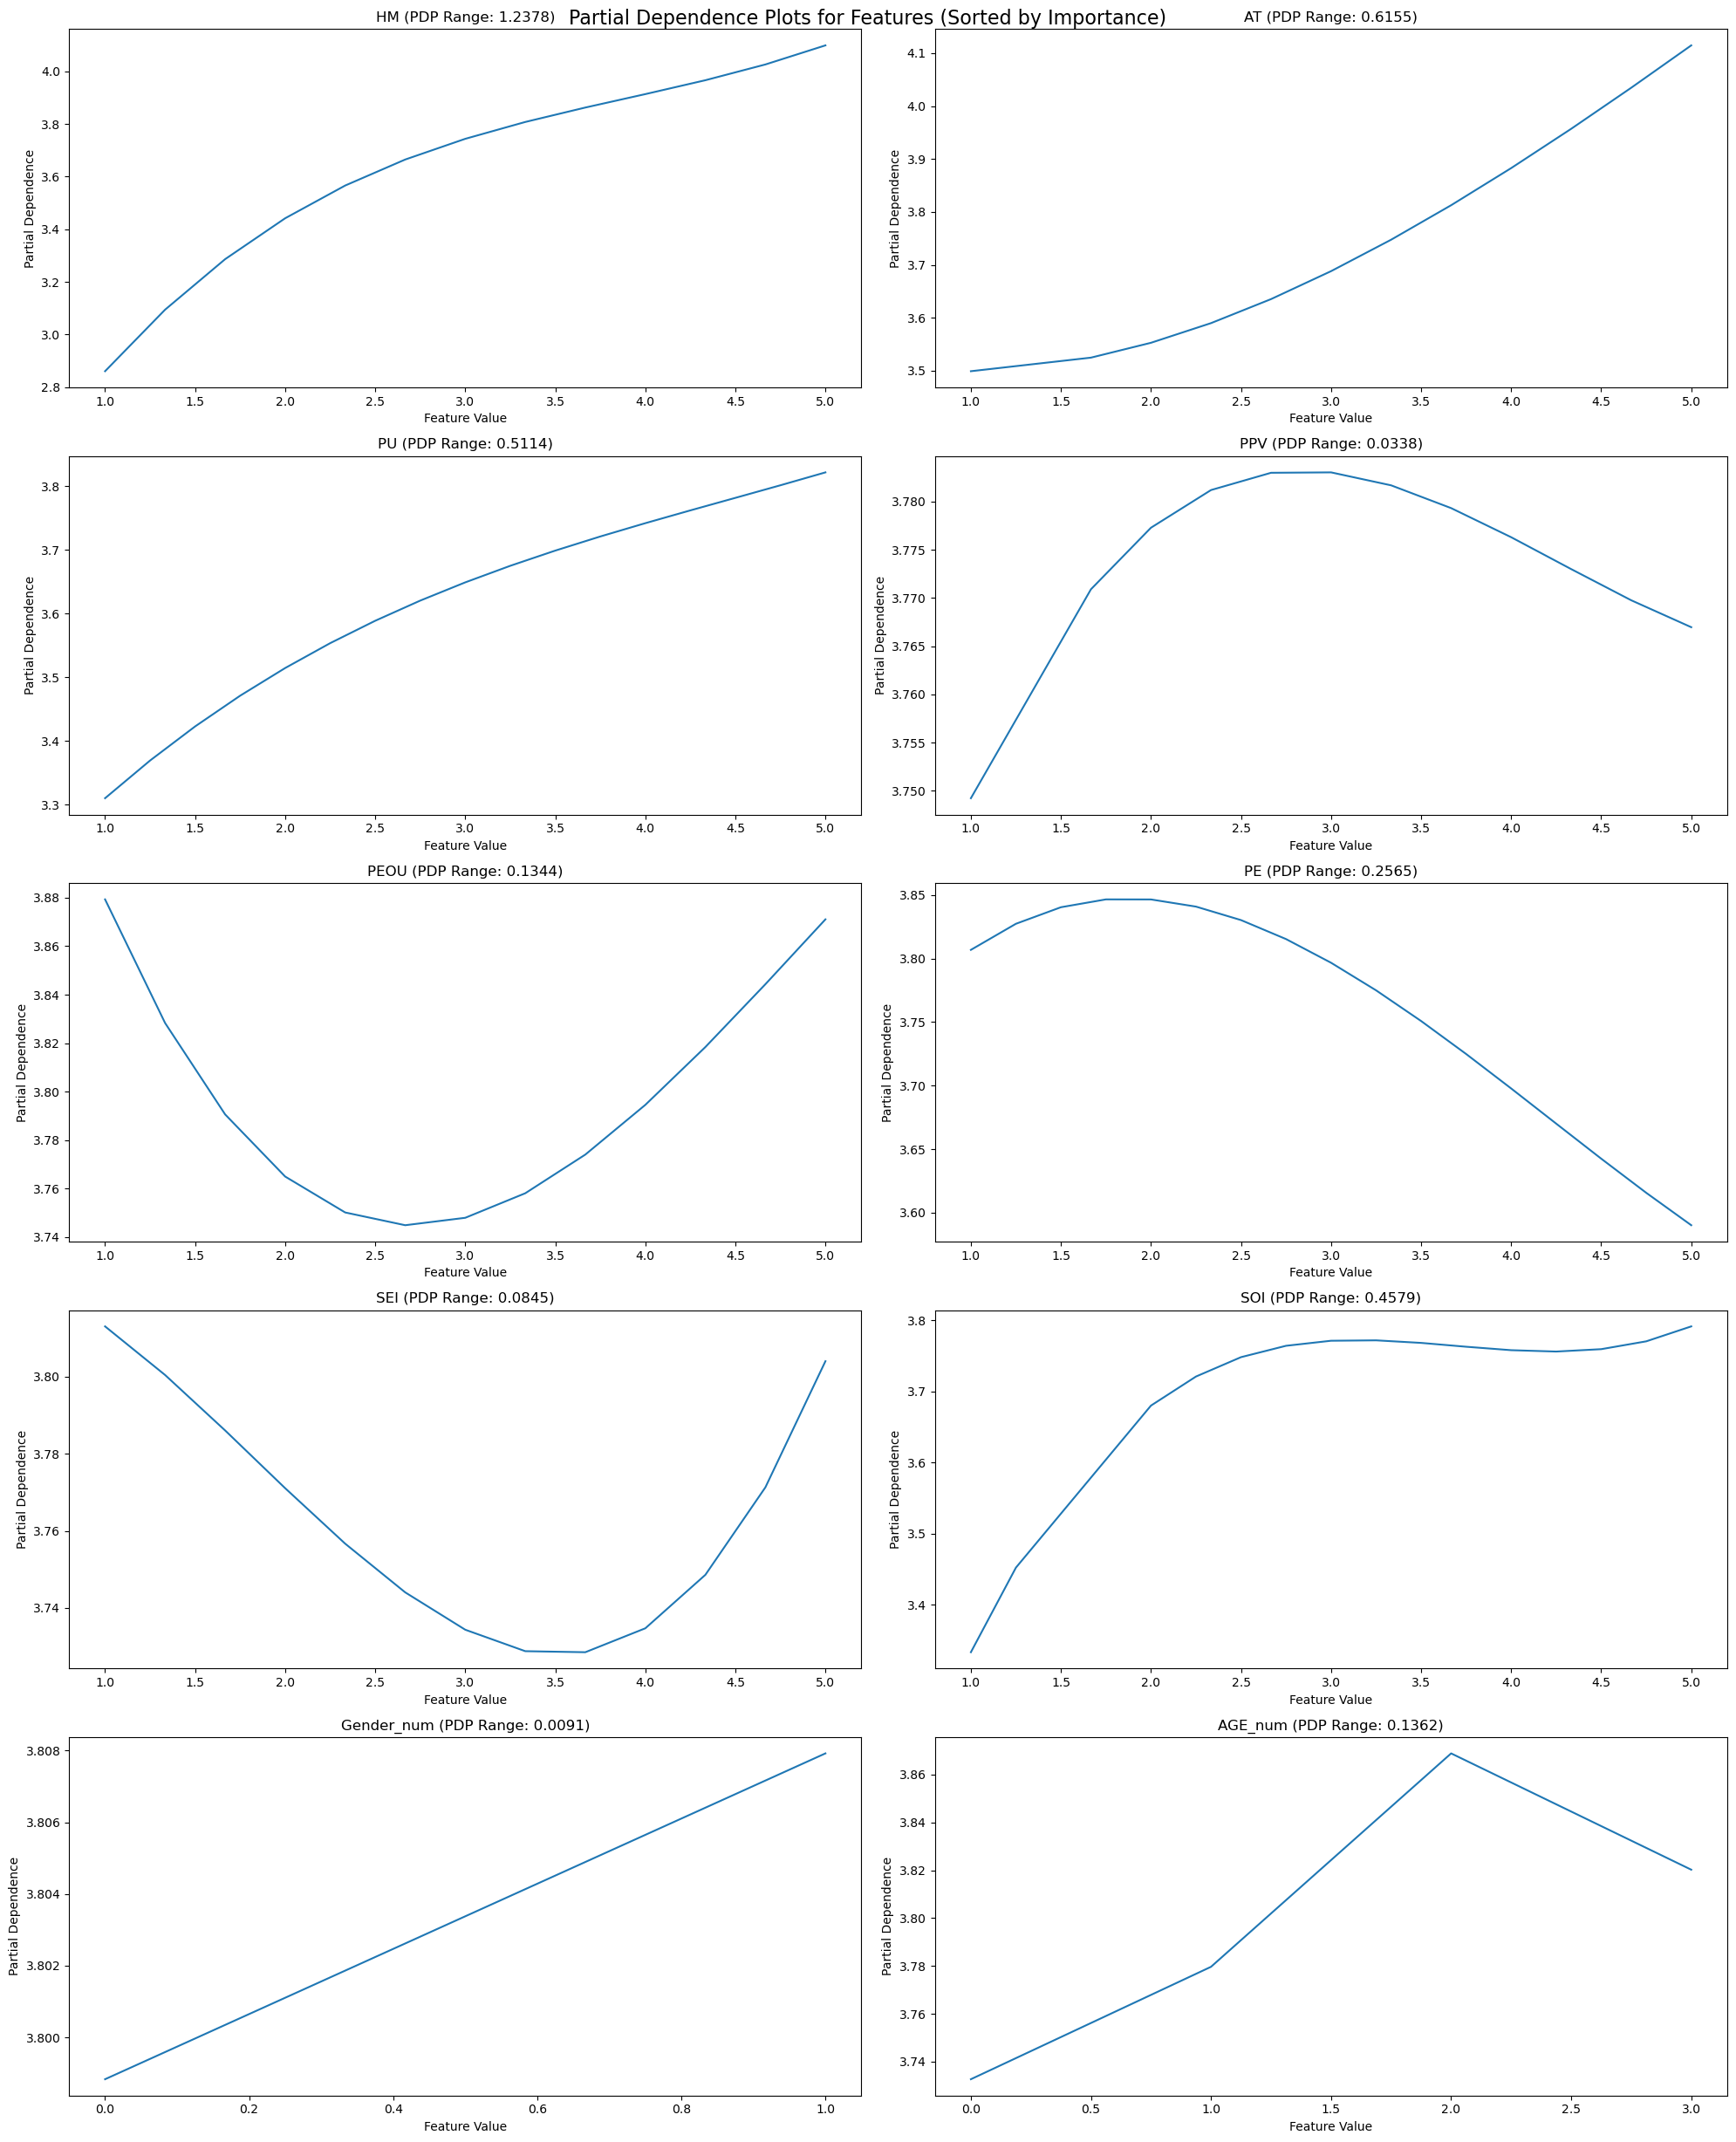

Results saved to JSON file: SVR_1__best_model_important_features.json

Feature Importance, MUI Scores, and PDP Ranges:
  model_name     feature  importance  mui_score  pdp_range
3        SVR          HM    0.268832   0.720583   1.237847
2        SVR          AT    0.123021   0.613589   0.615545
0        SVR          PU    0.104847   0.652057   0.511409
7        SVR         PPV    0.099959   0.651528   0.033812
1        SVR        PEOU    0.092049   0.554120   0.134429
4        SVR          PE    0.082137   0.513979   0.256529
6        SVR         SEI    0.078491   0.573950   0.084499
5        SVR         SOI    0.077049   0.564335   0.457901
9        SVR  Gender_num    0.000191   0.044231   0.009090
8        SVR     AGE_num   -0.002861   0.029399   0.136186

Feature importance dataframe saved to: svr_1_important_features.csv

Training set evaluation:
Training set MSE: 0.1393
Training set R2: 0.8204

Test set evaluation:
Test set MSE: 0.1584
Test set R2: 0.7743

Difference between train

<Figure size 1500x1000 with 0 Axes>

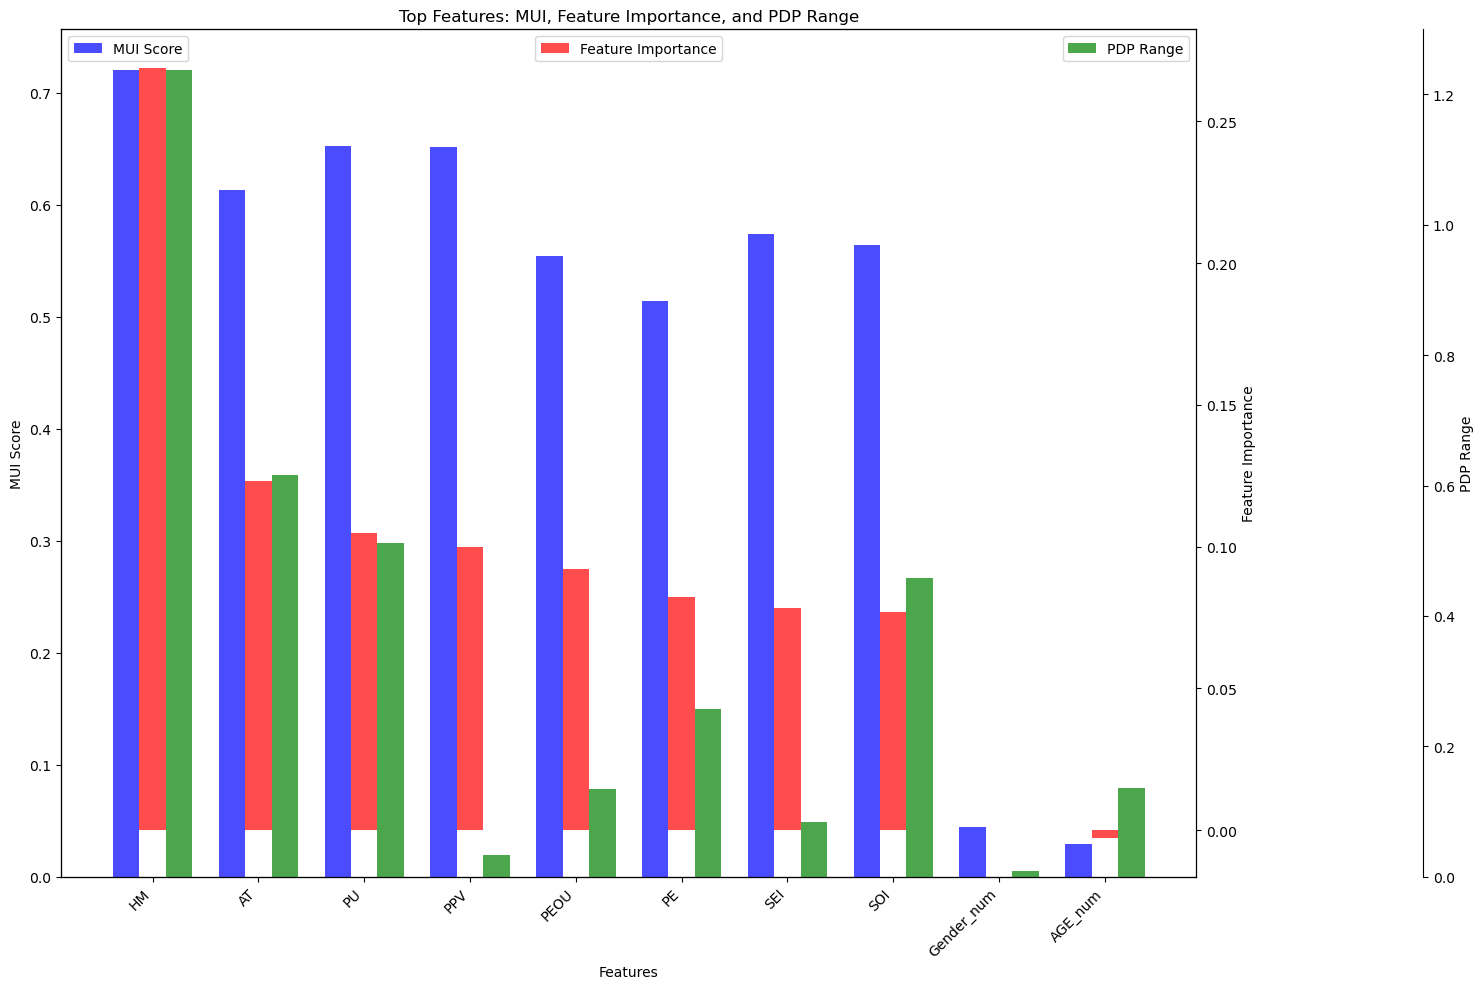

Combined plot of MUI, Feature Importance, and PDP Range has been saved.

Combined MUI, PDP, and Feature Importance saved to: svr_1_combined_importance.json
Combined importance saved to CSV: svr_1_combined_importance.csv
end of script 1


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, train_test_split, KFold
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.inspection import partial_dependence
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error, r2_score
import json

feature_vars = ['PU','PEOU','AT','HM','PE','SOI','SEI','PPV', 'AGE_num','Gender_num']
    

print(f"Number of features selected: {len(feature_vars)}")
print("Selected features:")
print(feature_vars)

X = df_survey_cleaned[feature_vars]
y = df_survey_cleaned['BI']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Separate numeric and categorical features
numeric_features = [col for col in feature_vars if col not in ['AGE_num', 'Gender_num']]
categorical_features = ['AGE_num', 'Gender_num']

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
        ,('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Perform cross-validation with MUI and feature importance
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = []
feature_importance = {feature: [] for feature in feature_vars}
mui_scores = {feature: [] for feature in feature_vars}

for train_index, val_index in kf.split(X_train):
    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # Preprocess the data
    preprocessor.fit(X_fold_train)
    X_fold_train_preprocessed = preprocessor.transform(X_fold_train)
    X_fold_val_preprocessed = preprocessor.transform(X_fold_val)
    
    # Calculate MUI scores
    mui_fold_scores = mutual_info_regression(X_fold_train_preprocessed, y_fold_train)
    for i, feature in enumerate(feature_vars):
        mui_scores[feature].append(mui_fold_scores[i])
    
    # Train the model
    model = SVR(kernel='rbf')
    model.fit(X_fold_train_preprocessed, y_fold_train)
    
    # Calculate feature importance (using permutation importance for SVR)
    perm_importance = permutation_importance(model, X_fold_val_preprocessed, y_fold_val, n_repeats=10, random_state=42)
    for i, feature in enumerate(feature_vars):
        feature_importance[feature].append(perm_importance.importances_mean[i])
    
    # Make predictions and calculate scores
    y_pred = model.predict(X_fold_val_preprocessed)
    mse = mean_squared_error(y_fold_val, y_pred)
    r2 = r2_score(y_fold_val, y_pred)
    
    cv_scores.append({'MSE': mse, 'R2': r2})

# Perform cross-validation on the best model
cv_results = cross_validate(model, X_train, y_train, cv=5,
                            scoring=('neg_mean_squared_error', 'r2'),
                            return_train_score=True)
# Calculate average scores
avg_mse = np.mean([score['MSE'] for score in cv_scores])
avg_r2 = np.mean([score['R2'] for score in cv_scores])

print(f"Average MSE: {avg_mse}")
print(f"Average R2: {avg_r2}")

# Extract scores from cv_results
train_mse = -cv_results['train_neg_mean_squared_error']
train_r2 = cv_results['train_r2']
test_mse = -cv_results['test_neg_mean_squared_error']
test_r2 = cv_results['test_r2']


print("SVR Regressor (Best Model) Results (5-fold Cross-Validation):")
print("--------------------------------")
print(f"Training MSE: {train_mse.mean():.4f} (+/- {train_mse.std() * 2:.4f})")
print(f"Training R^2: {train_r2.mean():.4f} (+/- {train_r2.std() * 2:.4f})")
print(f"Testing MSE: {test_mse.mean():.4f} (+/- {test_mse.std() * 2:.4f})")
print(f"Testing R^2: {test_r2.mean():.4f} (+/- {test_r2.std() * 2:.4f})")

# Create model_metrics dataframe
model_metrics = pd.DataFrame({
    'model_name': ['SVR 1 (TAM )'],
    'run_type': ['Initial Run'],
    'train_mse_mean': [train_mse.mean()],
    'train_mse_std': [train_mse.std()],
    'train_r2_mean': [train_r2.mean()],
    'train_r2_std': [train_r2.std()],
    'test_mse_mean': [test_mse.mean()],
    'test_mse_std': [test_mse.std()],
    'test_r2_mean': [test_r2.mean()],
    'test_r2_std': [test_r2.std()]})

model_metrics.to_csv('svr_1_model_metrics.csv', index=False)
print(f"SVR 1 Final model metrics saved to csv: svr_1_best_model_metrics.csv")

# Calculate average feature importance and MUI scores
avg_feature_importance = {feature: np.mean(scores) for feature, scores in feature_importance.items()}
avg_mui_scores = {feature: np.mean(scores) for feature, scores in mui_scores.items()}

# Sort features by importance
sorted_features = sorted(avg_feature_importance.items(), key=lambda x: x[1], reverse=True)
top_features = [feature for feature, _ in sorted_features[:15]]

# Fit the final model on the entire training set
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVR(kernel='poly'))
])
pipeline.fit(X_train, y_train)

# Calculate PDP values for top features
pdp_values = {}
pdp_ranges = {}

for feature in top_features:
    pdp = partial_dependence(pipeline, X_train, [feature], kind="average")
    pdp_values[feature] = (pdp["values"][0], pdp["average"][0])
    pdp_ranges[feature] = np.ptp(pdp["average"][0])  # Range of PDP values
 
# Plot PDP for all features with calculated PDP values (sorted by importance)
features_with_pdp = [feature for feature in top_features if feature in pdp_values]
n_features = len(features_with_pdp)
n_rows = (n_features + 1) // 2  # Calculate the number of rows needed
fig, axes = plt.subplots(n_rows, 2, figsize=(20, 5 * n_rows))
fig.suptitle("Partial Dependence Plots for Features (Sorted by Importance)", fontsize=16)

for i, feature in enumerate(features_with_pdp):
    row = i // 2
    col = i % 2
    ax = axes[row, col] if n_rows > 1 else axes[col]
    x, y = pdp_values[feature]
    ax.plot(x, y)
    ax.set_title(f"{feature} (PDP Range: {pdp_ranges[feature]:.4f})")
    ax.set_xlabel("Feature Value")
    ax.set_ylabel("Partial Dependence")

# Remove any unused subplots
if n_features % 2 != 0:
    fig.delaxes(axes[n_rows-1, 1])

plt.tight_layout()
plt.show()
plt.savefig('svr_best_model_pdp_plots_sorted.png', dpi=300, bbox_inches='tight')
plt.close()
##-----

# Create results dictionary
results = {
    'top_features': top_features,
    'feature_importance': {feature: avg_feature_importance[feature] for feature in top_features},
    'mui_scores': {feature: avg_mui_scores[feature] for feature in top_features},
    'pdp_values': {feature: pdp_values[feature][1].tolist() for feature in top_features},
    'pdp_feature_values': {feature: pdp_values[feature][0].tolist() for feature in top_features}
}

import os
import json

# Define the file name
file_name = 'SVR_1__best_model_important_features.json'

# Get the current directory
current_directory = os.getcwd()

# Create the full file path
file_path = os.path.join(current_directory, file_name)

# Save results to JSON file in the current directory
with open(file_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved to JSON file: {file_name}")

# Create svr_important_features dataframe
svr_important_features = pd.DataFrame([
    {'feature': feature, 'importance': avg_feature_importance[feature], 
     'mui_score': avg_mui_scores[feature], 'pdp_range': pdp_ranges.get(feature, np.nan)}
    for feature in feature_vars
])
svr_important_features = svr_important_features.sort_values('importance', ascending=False)
svr_important_features.insert(0, 'model_name', 'SVR')

print("\nFeature Importance, MUI Scores, and PDP Ranges:")
print(svr_important_features)

# Save dataframe to CSV file
svr_important_features.to_csv('svr_1_important_features.csv', index=False)
print("\nFeature importance dataframe saved to: svr_1_important_features.csv")

# Evaluate the model on the training set
y_train_pred = pipeline.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
print("\nTraining set evaluation:")
print(f"Training set MSE: {train_mse:.4f}")
print(f"Training set R2: {train_r2:.4f}")

# Evaluate the model on the test set
y_test_pred = pipeline.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print("\nTest set evaluation:")
print(f"Test set MSE: {test_mse:.4f}")
print(f"Test set R2: {test_r2:.4f}")

# Calculate and print the difference between training and test performance
mse_difference = train_mse - test_mse
r2_difference = train_r2 - test_r2
print("\nDifference between training and test performance:")
print(f"MSE difference (train - test): {mse_difference:.4f}")
print(f"R2 difference (train - test): {r2_difference:.4f}")

# Create a combined bar plot for MUI, Feature Importance, and PDP Range
plt.figure(figsize=(15, 10))
x = range(len(top_features))
width = 0.25

fig, ax1 = plt.subplots(figsize=(15, 10))
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# Offset the right spine of ax3 by 60 points
ax3.spines['right'].set_position(('axes', 1.2))

rects1 = ax1.bar([i - width for i in x], [avg_mui_scores[f] for f in top_features], width, label='MUI Score', color='b', alpha=0.7)
rects2 = ax2.bar(x, [avg_feature_importance[f] for f in top_features], width, label='Feature Importance', color='r', alpha=0.7)
rects3 = ax3.bar([i + width for i in x], [pdp_ranges[f] for f in top_features], width, label='PDP Range', color='g', alpha=0.7)

ax1.set_xlabel('Features')
ax1.set_ylabel('MUI Score')
ax2.set_ylabel('Feature Importance')
ax3.set_ylabel('PDP Range')
ax1.set_title('Top Features: MUI, Feature Importance, and PDP Range')
ax1.set_xticks(x)
ax1.set_xticklabels(top_features, rotation=45, ha='right')

ax1.legend(loc='upper left')
ax2.legend(loc='upper center')
ax3.legend(loc='upper right')

fig.tight_layout()
plt.show()
plt.savefig('svr_top_features_mui_importance_pdp.png', dpi=300, bbox_inches='tight')
plt.close()

print("Combined plot of MUI, Feature Importance, and PDP Range has been saved.")

# Combine MUI, PDP, and Feature Importance
combined_importance = pd.DataFrame({
    'feature': feature_vars,
    'mui_score': [avg_mui_scores[f] for f in feature_vars],
    'feature_importance': [avg_feature_importance[f] for f in feature_vars],
    'pdp_range': [pdp_ranges.get(f, np.nan) for f in feature_vars]
})

# Sort by feature importance
combined_importance = combined_importance.sort_values('feature_importance', ascending=False)

# Save combined importance to JSON
with open('svr_1_combined_importance.json', 'w') as f:
    json.dump(combined_importance.to_dict(orient='records'), f, indent=2)

print("\nCombined MUI, PDP, and Feature Importance saved to: svr_1_combined_importance.json")

import os

# Save combined importance to CSV in the current directory
current_directory = os.getcwd()
file_name = 'svr_1_combined_importance.csv'
file_path = os.path.join(current_directory, file_name)

combined_importance.to_csv(file_path, index=False)
print(f"Combined importance saved to CSV: {file_name}")

print('end of script 1')

## 2. SVR Model using PCA Feature List

2. SVR Model using PCA Feature List
Type of pca_selected_features: <class 'list'>
First few items in pca_selected_features:
  AGEGender_centered_squared (type: <class 'str'>)
  AGEGender_centered (type: <class 'str'>)
  GenderPEOU_centered_squared (type: <class 'str'>)
  AGEPEOU_centered_squared (type: <class 'str'>)
  GenderPEOU_centered (type: <class 'str'>)

Successfully loaded 10 unique PCA selected features.

First 5 features:
- AGEGender_centered_squared
- AGEGender_centered
- GenderPEOU_centered_squared
- AGEPEOU_centered_squared
- GenderPEOU_centered

Last 5 features:
- HMSOI_centered
- PEAT_centered
- HMPE_centered
- AGE_num_1
- AGE_num_2

Number of unique features: 10
Number of features selected: 64
Selected features:
['AGEGender_centered_squared', 'AGEGender_centered', 'GenderPEOU_centered_squared', 'AGEPEOU_centered_squared', 'GenderPEOU_centered', 'AGESOI_centered_squared', 'AGESEI_centered_squared', 'PEOU_centered_squared', 'AGEPEOU_centered', 'PEOU_centered', 'AGEPPV_cen

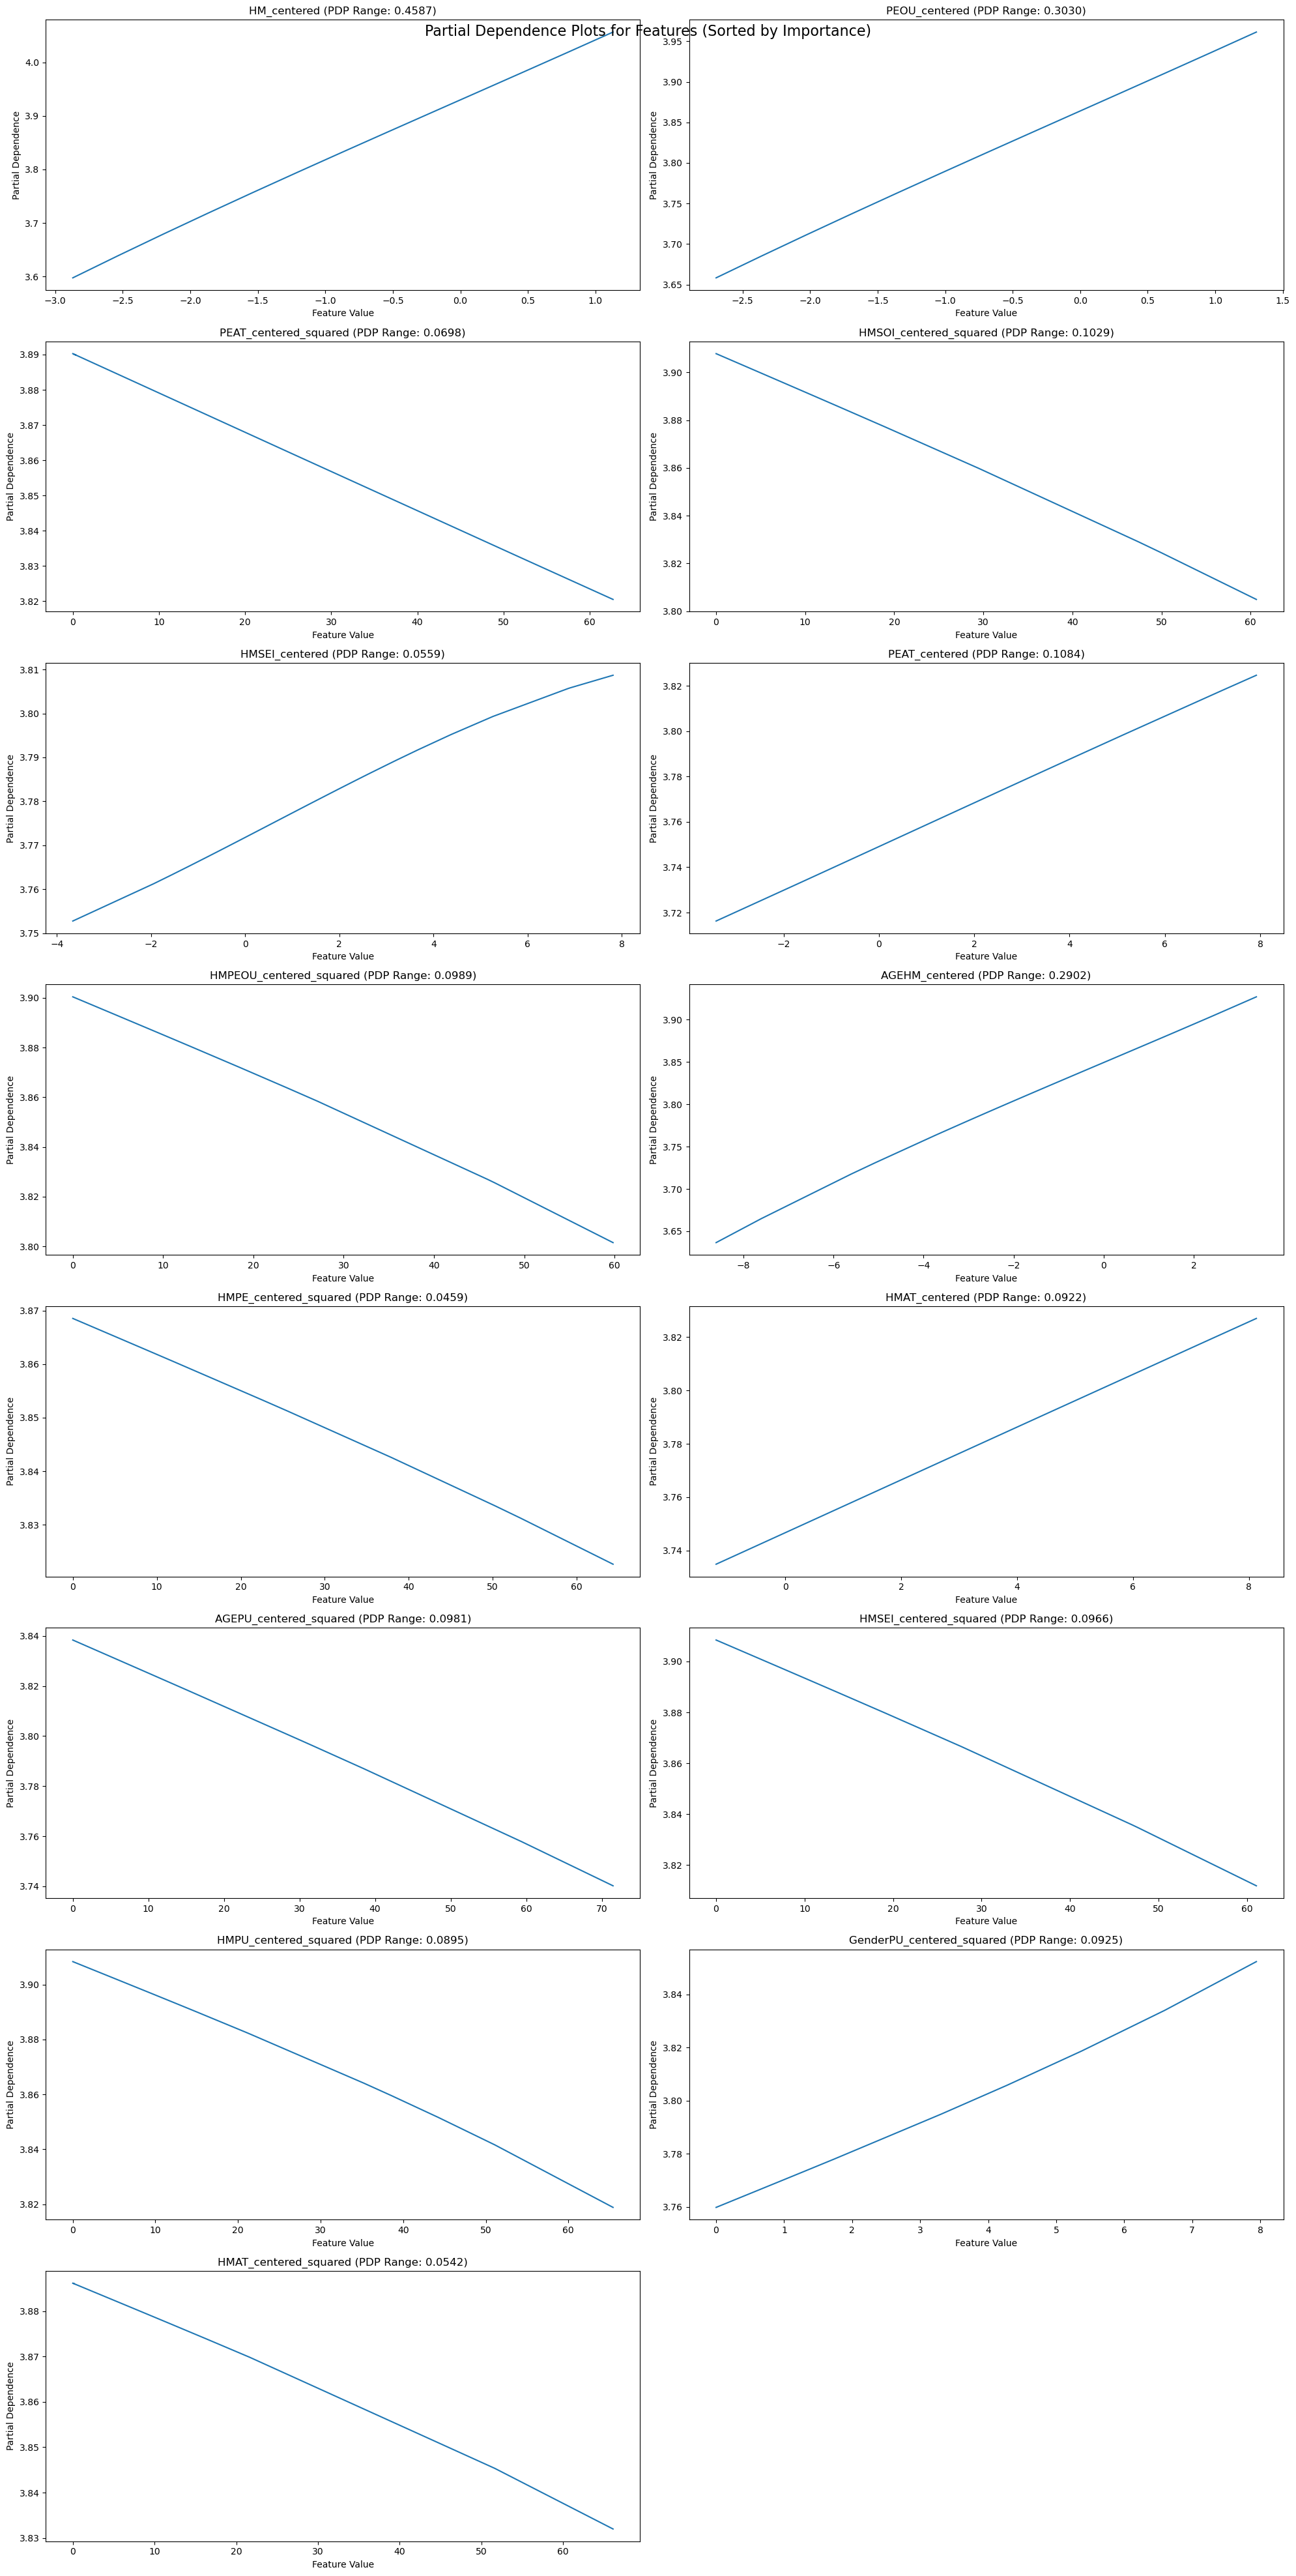


Feature analysis results saved to: feature_analysis_results_svr.json

SVR 2 Feature Importance, MUI Scores, and PDP Ranges:
   model_name                      feature  importance  mui_score  pdp_range
39        SVR                  HM_centered    0.060119   0.715557   0.458653
9         SVR                PEOU_centered    0.027462   0.564476   0.302996
53        SVR        PEAT_centered_squared    0.026597   0.499010   0.069783
48        SVR       HMSOI_centered_squared    0.025958   0.532165   0.102936
43        SVR               HMSEI_centered    0.025737   0.639022   0.055931
58        SVR                PEAT_centered    0.024667   0.509300   0.108369
46        SVR      HMPEOU_centered_squared    0.024346   0.605273   0.098866
34        SVR               AGEHM_centered    0.023570   0.617745   0.290214
51        SVR        HMPE_centered_squared    0.023220   0.586643   0.045857
50        SVR                HMAT_centered    0.023081   0.646846   0.092183
16        SVR       AGEPU_ce

<Figure size 1500x1000 with 0 Axes>

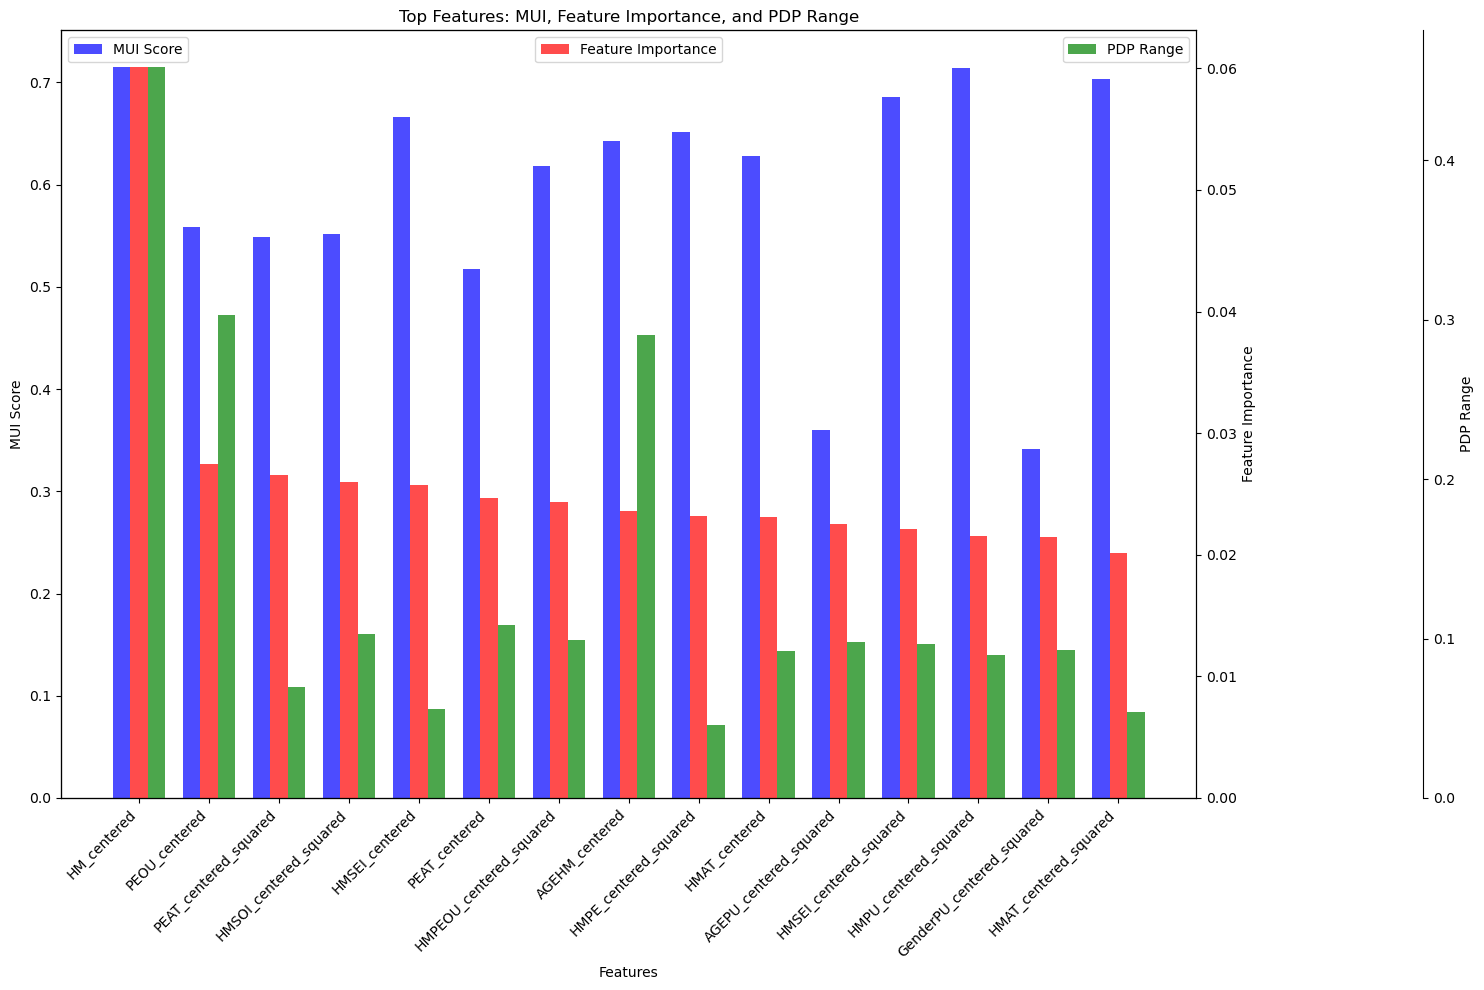

SVR 2 Combined plot of MUI, Feature Importance, and PDP Range has been saved.
SVR 2 Combined top 15 features: ['HMPU_centered', 'HM_centered', 'HMPU_centered_squared', 'HMAT_centered_squared', 'HMSEI_centered_squared', 'HMSEI_centered', 'PU_centered_squared', 'HM_centered_squared', 'HMPE_centered', 'HMPE_centered_squared', 'PU_centered', 'AGEHM_centered', 'HMPEOU_centered', 'HMAT_centered', 'PPV_centered']
Top 15 important features saved to JSON file: svr_2_top_15_combined_features.json
SVR 2 Updated feature importance DataFrame (including MUI scores) saved to: svr_2_important_features.csv
End of Script 2


In [71]:
print('2. SVR Model using PCA Feature List')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, train_test_split, KFold
from sklearn.svm import SVR
from sklearn.inspection import partial_dependence
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error, r2_score
import json

# Open and read the JSON file
try:
    with open('PCA_selected_features.json', 'r') as json_file:
        feature_data = json.load(json_file)

    # Extract the list of selected features
    pca_selected_features = feature_data['PCA_selected_features']

    print("Type of pca_selected_features:", type(pca_selected_features))
    print("First few items in pca_selected_features:")
    for item in pca_selected_features[:5]:
        print(f"  {item} (type: {type(item)})")

    # If pca_selected_features is a list of strings, use this:
    selected_features = list(dict.fromkeys(pca_selected_features))

    print(f"\nSuccessfully loaded {len(feature_vars)} unique PCA selected features.")
    print("\nFirst 5 features:")
    for feature in selected_features[:5]:
        print(f"- {feature}")

    print(f"\nLast 5 features:")
    for feature in selected_features[-5:]:
        print(f"- {feature}")

    print(f"\nNumber of unique features: {len(feature_vars)}")

except FileNotFoundError:
    print("Error: The file 'PCA_selected_features.json' was not found.")
except json.JSONDecodeError:
    print("Error: There was a problem decoding the JSON file.")
except KeyError:
    print("Error: The key 'PCA_selected_features' was not found in the JSON file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    
# Select the first 30 features from feature_vars
#feature_vars = selected_features[:30]

feature_vars = selected_features

print(f"Number of features selected: {len(feature_vars)}")
print("Selected features:")
print(feature_vars)

# AGE and Gender are both numerical categorical features, check to see if AGE_num_1, 2,3 and Gender_num_1 are in the PCA list but not in df_survey_cleaned
missing_columns = [col for col in feature_vars if col not in df_survey_cleaned.columns]
print("Missing columns:", missing_columns)

# First, check if 'AGE' and 'Gender' columns exist
if 'AGE_num' in df_survey_cleaned.columns:
    # Create age dummy variables
    df_survey_cleaned['AGE_num_1'] = (df_survey_cleaned['AGE_num'] == 1).astype(int)
    df_survey_cleaned['AGE_num_2'] = (df_survey_cleaned['AGE_num'] == 2).astype(int)
    df_survey_cleaned['AGE_num_3'] = (df_survey_cleaned['AGE_num'] == 3).astype(int)

if 'Gender_num' in df_survey_cleaned.columns:
    # Create age dummy variables
    df_survey_cleaned['Gender_num_1'] = (df_survey_cleaned['Gender_num'] == 1).astype(int)

for col in feature_vars:
    if df_survey_cleaned[col].dtype == 'object':
        if df_survey_cleaned[col].nunique() == 2:
            # Binary variable
            df_survey_cleaned[col] = pd.get_dummies(df_survey_cleaned[col], drop_first=True)
        else:
            # Categorical variable
            dummies = pd.get_dummies(df_survey_cleaned[col], prefix=col, drop_first=True)
            df_survey_cleaned = pd.concat([df_survey_cleaned, dummies], axis=1)
            feature_vars.extend(dummies.columns)
            feature_vars.remove(col)

# Convert boolean columns to int
bool_columns = df_survey_cleaned[feature_vars].select_dtypes(include=['bool']).columns
df_survey_cleaned[bool_columns] = df_survey_cleaned[bool_columns].astype(int)

# Ensure all features are numeric
feature_vars = [col for col in feature_vars if df_survey_cleaned[col].dtype in ['int64', 'float64']]

print("Updated feature variables:", feature_vars)
print(df_survey_cleaned[feature_vars].dtypes)

feature_vars = selected_features

print(f"Number of features selected: {len(feature_vars)}")
print("Selected features:")
print(feature_vars)

# AGE and Gender are both numerical categorical features, check to see if AGE_num_1, 2,3 and Gender_num_1 are in the PCA list but not in df_survey_cleaned
missing_columns = [col for col in feature_vars if col not in df_survey_cleaned.columns]
print("Missing columns:", missing_columns)

# First, check if 'AGE' and 'Gender' columns exist
if 'AGE_num' in df_survey_cleaned.columns:
    # Create age dummy variables
    df_survey_cleaned['AGE_num_1'] = (df_survey_cleaned['AGE_num'] == 1).astype(int)
    df_survey_cleaned['AGE_num_2'] = (df_survey_cleaned['AGE_num'] == 2).astype(int)
    df_survey_cleaned['AGE_num_3'] = (df_survey_cleaned['AGE_num'] == 3).astype(int)

if 'Gender_num' in df_survey_cleaned.columns:
    # Create age dummy variables
    df_survey_cleaned['Gender_num_1'] = (df_survey_cleaned['Gender_num'] == 1).astype(int)

for col in feature_vars:
    if df_survey_cleaned[col].dtype == 'object':
        if df_survey_cleaned[col].nunique() == 2:
            # Binary variable
            df_survey_cleaned[col] = pd.get_dummies(df_survey_cleaned[col], drop_first=True)
        else:
            # Categorical variable
            dummies = pd.get_dummies(df_survey_cleaned[col], prefix=col, drop_first=True)
            df_survey_cleaned = pd.concat([df_survey_cleaned, dummies], axis=1)
            feature_vars.extend(dummies.columns)
            feature_vars.remove(col)

# Convert boolean columns to int
bool_columns = df_survey_cleaned[feature_vars].select_dtypes(include=['bool']).columns
df_survey_cleaned[bool_columns] = df_survey_cleaned[bool_columns].astype(int)

# Ensure all features are numeric
feature_vars = [col for col in feature_vars if df_survey_cleaned[col].dtype in ['int64', 'float64']]

print("Updated feature variables:", feature_vars)
print(df_survey_cleaned[feature_vars].dtypes)

X = df_survey_cleaned[feature_vars]
y = df_survey_cleaned['BI']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Separate numeric and categorical features
numeric_features = [col for col in feature_vars if col not in ['AGE_num', 'Gender_num']]
categorical_features = ['AGE_num', 'Gender_num']

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
        ,#('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Perform cross-validation with MUI and feature importance
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = []
feature_importance = {feature: [] for feature in feature_vars}
mui_scores = {feature: [] for feature in feature_vars}

for train_index, val_index in kf.split(X_train):
    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # Preprocess the data
    preprocessor.fit(X_fold_train)
    X_fold_train_preprocessed = preprocessor.transform(X_fold_train)
    X_fold_val_preprocessed = preprocessor.transform(X_fold_val)
    
    # Calculate MUI scores
    mui_fold_scores = mutual_info_regression(X_fold_train_preprocessed, y_fold_train)
    for i, feature in enumerate(feature_vars):
        mui_scores[feature].append(mui_fold_scores[i])
    
    # Train the model
    model = SVR(kernel='rbf')
    model.fit(X_fold_train_preprocessed, y_fold_train)
    
    # Calculate feature importance (using permutation importance for SVR)
    perm_importance = permutation_importance(model, X_fold_val_preprocessed, y_fold_val, n_repeats=10, random_state=42)
    for i, feature in enumerate(feature_vars):
        feature_importance[feature].append(perm_importance.importances_mean[i])
    
    # Make predictions and calculate scores
    y_pred = model.predict(X_fold_val_preprocessed)
    mse = mean_squared_error(y_fold_val, y_pred)
    r2 = r2_score(y_fold_val, y_pred)
    
    cv_scores.append({'MSE': mse, 'R2': r2})

# Calculate average scores
avg_mse = np.mean([score['MSE'] for score in cv_scores])
avg_r2 = np.mean([score['R2'] for score in cv_scores])

print(f"Average MSE: {avg_mse}")
print(f"Average R2: {avg_r2}")

# Perform cross-validation on the best model
cv_results = cross_validate(model, X_train, y_train, cv=5,
                            scoring=('neg_mean_squared_error', 'r2'),
                            return_train_score=True)

# Extract scores from cv_results
train_mse = -cv_results['train_neg_mean_squared_error']
train_r2 = cv_results['train_r2']
test_mse = -cv_results['test_neg_mean_squared_error']
test_r2 = cv_results['test_r2']


print("SVR Regressor (Best Model) Results (5-fold Cross-Validation):")
print("--------------------------------")
print(f"Training MSE: {train_mse.mean():.4f} (+/- {train_mse.std() * 2:.4f})")
print(f"Training R^2: {train_r2.mean():.4f} (+/- {train_r2.std() * 2:.4f})")
print(f"Testing MSE: {test_mse.mean():.4f} (+/- {test_mse.std() * 2:.4f})")
print(f"Testing R^2: {test_r2.mean():.4f} (+/- {test_r2.std() * 2:.4f})")

# Create model_metrics dataframe
model_metrics = pd.DataFrame({
    'model_name': ['SVR 2 (PCA)'],
    'run_type': ['2nd Run'],
    'train_mse_mean': [train_mse.mean()],
    'train_mse_std': [train_mse.std()],
    'train_r2_mean': [train_r2.mean()],
    'train_r2_std': [train_r2.std()],
    'test_mse_mean': [test_mse.mean()],
    'test_mse_std': [test_mse.std()],
    'test_r2_mean': [test_r2.mean()],
    'test_r2_std': [test_r2.std()]})

model_metrics.to_csv('svr_2_model_metrics.csv', index=False)
print(f"SVR 2 model metrics saved to csv: svr_2_model_metrics.csv")

# Calculate average feature importance and MUI scores
avg_feature_importance = {feature: np.mean(scores) for feature, scores in feature_importance.items()}
avg_mui_scores = {feature: np.mean(scores) for feature, scores in mui_scores.items()}

# Sort features by importance
sorted_features = sorted(avg_feature_importance.items(), key=lambda x: x[1], reverse=True)
top_features = [feature for feature, _ in sorted_features[:15]]

# Fit the final model on the entire training set
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVR(kernel='poly'))
])
pipeline.fit(X_train, y_train)

# Calculate PDP values for top features
pdp_values = {}
pdp_ranges = {}

for feature in top_features:
    pdp = partial_dependence(pipeline, X_train, [feature], kind="average")
    pdp_values[feature] = (pdp["values"][0], pdp["average"][0])
    pdp_ranges[feature] = np.ptp(pdp["average"][0])  # Range of PDP values


# Plot PDP for all features with calculated PDP values (sorted by importance)
features_with_pdp = [feature for feature in top_features if feature in pdp_values]
n_features = len(features_with_pdp)
n_rows = (n_features + 1) // 2  # Calculate the number of rows needed
fig, axes = plt.subplots(n_rows, 2, figsize=(20, 5 * n_rows))
fig.suptitle("Partial Dependence Plots for Features (Sorted by Importance)", fontsize=16)

for i, feature in enumerate(features_with_pdp):
    row = i // 2
    col = i % 2
    ax = axes[row, col] if n_rows > 1 else axes[col]
    x, y = pdp_values[feature]
    ax.plot(x, y)
    ax.set_title(f"{feature} (PDP Range: {pdp_ranges[feature]:.4f})")
    ax.set_xlabel("Feature Value")
    ax.set_ylabel("Partial Dependence")

# Remove any unused subplots
if n_features % 2 != 0:
    fig.delaxes(axes[n_rows-1, 1])

plt.tight_layout()
plt.show()
plt.savefig('svr_2_best_model_pdp_plots_sorted.png', dpi=300, bbox_inches='tight')
plt.close()
 
# Create results dictionary
results = {
    'top_features': top_features,
    'feature_importance': {feature: avg_feature_importance[feature] for feature in top_features},
    'mui_scores': {feature: avg_mui_scores[feature] for feature in top_features},
    'pdp_values': {feature: pdp_values[feature][1].tolist() for feature in top_features},
    'pdp_feature_values': {feature: pdp_values[feature][0].tolist() for feature in top_features}
}

# Save results to JSON file
with open('svr_2_feature_analysis_results_svr.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nFeature analysis results saved to: feature_analysis_results_svr.json")

# Create svr_important_features dataframe
svr_2_important_features = pd.DataFrame([
    {'feature': feature, 'importance': avg_feature_importance[feature], 
     'mui_score': avg_mui_scores[feature], 'pdp_range': pdp_ranges.get(feature, np.nan)}
    for feature in feature_vars
])
svr_2_important_features = svr_2_important_features.sort_values('importance', ascending=False)
svr_2_important_features.insert(0, 'model_name', 'SVR')

print("\nSVR 2 Feature Importance, MUI Scores, and PDP Ranges:")
print(svr_2_important_features)

# Save dataframe to CSV file
svr_2_important_features.to_csv('svr_2_important_features.csv', index=False)
print("\nSVR 2 Feature importance dataframe saved to: svr_2_important_features.csv")

# Evaluate the model on the training set
y_train_pred = pipeline.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
print("\nTraining set evaluation:")
print(f"Training set MSE: {train_mse:.4f}")
print(f"Training set R2: {train_r2:.4f}")

# Evaluate the model on the test set
y_test_pred = pipeline.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print("\nTest set evaluation:")
print(f"Test set MSE: {test_mse:.4f}")
print(f"Test set R2: {test_r2:.4f}")

# Calculate and print the difference between training and test performance
mse_difference = train_mse - test_mse
r2_difference = train_r2 - test_r2
print("\nDifference between training and test performance:")
print(f"MSE difference (train - test): {mse_difference:.4f}")
print(f"R2 difference (train - test): {r2_difference:.4f}")

# Calculate MUI scores for the entire training set
X_train_preprocessed = preprocessor.fit_transform(X_train)
mui_scores = mutual_info_regression(X_train_preprocessed, y_train)
mui_dict = dict(zip(feature_vars, mui_scores))

# Create a combined bar plot for MUI, Feature Importance, and PDP Range
plt.figure(figsize=(15, 10))
x = range(len(top_features))
width = 0.25

fig, ax1 = plt.subplots(figsize=(15, 10))
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# Offset the right spine of ax3 by 60 points
ax3.spines['right'].set_position(('axes', 1.2))

rects1 = ax1.bar([i - width for i in x], [mui_dict[f] for f in top_features], width, label='MUI Score', color='b', alpha=0.7)
rects2 = ax2.bar(x, [avg_feature_importance[f] for f in top_features], width, label='Feature Importance', color='r', alpha=0.7)
rects3 = ax3.bar([i + width for i in x], [pdp_ranges[f] for f in top_features], width, label='PDP Range', color='g', alpha=0.7)

ax1.set_xlabel('Features')
ax1.set_ylabel('MUI Score')
ax2.set_ylabel('Feature Importance')
ax3.set_ylabel('PDP Range')
ax1.set_title('Top Features: MUI, Feature Importance, and PDP Range')
ax1.set_xticks(x)
ax1.set_xticklabels(top_features, rotation=45, ha='right')

ax1.legend(loc='upper left')
ax2.legend(loc='upper center')
ax3.legend(loc='upper right')

fig.tight_layout()
plt.show()
plt.savefig('svr_2_top_features_mui_importance_pdp.png', dpi=300, bbox_inches='tight')
plt.close()

print("SVR 2 Combined plot of MUI, Feature Importance, and PDP Range has been saved.")

# Update the results dictionary to include MUI scores
results['mui_scores'] = {feature: mui_dict[feature] for feature in top_features}

# Get top 15 features based on MUI scores
mui_top_15 = sorted(mui_dict.items(), key=lambda x: x[1], reverse=True)[:15]
mui_top_15_names = [feature for feature, _ in mui_top_15]

# Get top 15 features based on PDP ranges
pdp_top_15 = sorted(pdp_ranges.items(), key=lambda x: x[1], reverse=True)[:15]
pdp_top_15_names = [feature for feature, _ in pdp_top_15]

# Get top 15 features based on feature importance
importance_top_15 = sorted(avg_feature_importance.items(), key=lambda x: x[1], reverse=True)[:15]
importance_top_15_names = [feature for feature, _ in importance_top_15]

# Combine all top features and remove duplicates while preserving order
all_top_features = mui_top_15_names + pdp_top_15_names + importance_top_15_names
top_15_feature_names = list(dict.fromkeys(all_top_features))[:15]

print(f"SVR 2 Combined top 15 features: {top_15_feature_names}")

import os
import json

# Define the file name
file_name = 'svr_2_top_15_combined_features.json'

# Get the current directory
current_directory = os.getcwd()

# Create the full file path
file_path = os.path.join(current_directory, file_name)

# Save the top 15 important features to a JSON file in the current directory
with open(file_path, 'w') as f:
    json.dump(top_15_feature_names, f, indent=4)

print(f"Top 15 important features saved to JSON file: {file_name}")

 
# Update the svr_important_features DataFrame to include MUI scores
svr_important_features['mui_score'] = svr_important_features['feature'].map(mui_dict)

# Save DataFrame to CSV
svr_important_features.to_csv('svr_2_important_features.csv', index=False)
print("SVR 2 Updated feature importance DataFrame (including MUI scores) saved to: svr_2_important_features.csv")

print('End of Script 2')

### 3. SVR Model using PCA Feature List - Perform Random Grid Search.

3. SVR Model using PCA Feature List - Perform Random Grid Search
Type of pca_selected_features: <class 'list'>
First few items in pca_selected_features:
  AGEGender_centered_squared (type: <class 'str'>)
  AGEGender_centered (type: <class 'str'>)
  GenderPEOU_centered_squared (type: <class 'str'>)
  AGEPEOU_centered_squared (type: <class 'str'>)
  GenderPEOU_centered (type: <class 'str'>)

Successfully loaded 64 unique PCA selected features.

First 5 features:
- AGEGender_centered_squared
- AGEGender_centered
- GenderPEOU_centered_squared
- AGEPEOU_centered_squared
- GenderPEOU_centered

Last 5 features:
- HMSOI_centered
- PEAT_centered
- HMPE_centered
- AGE_num_1
- AGE_num_2

Number of unique features: 64
Number of features selected: 64
Selected features:
['AGEGender_centered_squared', 'AGEGender_centered', 'GenderPEOU_centered_squared', 'AGEPEOU_centered_squared', 'GenderPEOU_centered', 'AGESOI_centered_squared', 'AGESEI_centered_squared', 'PEOU_centered_squared', 'AGEPEOU_centered',

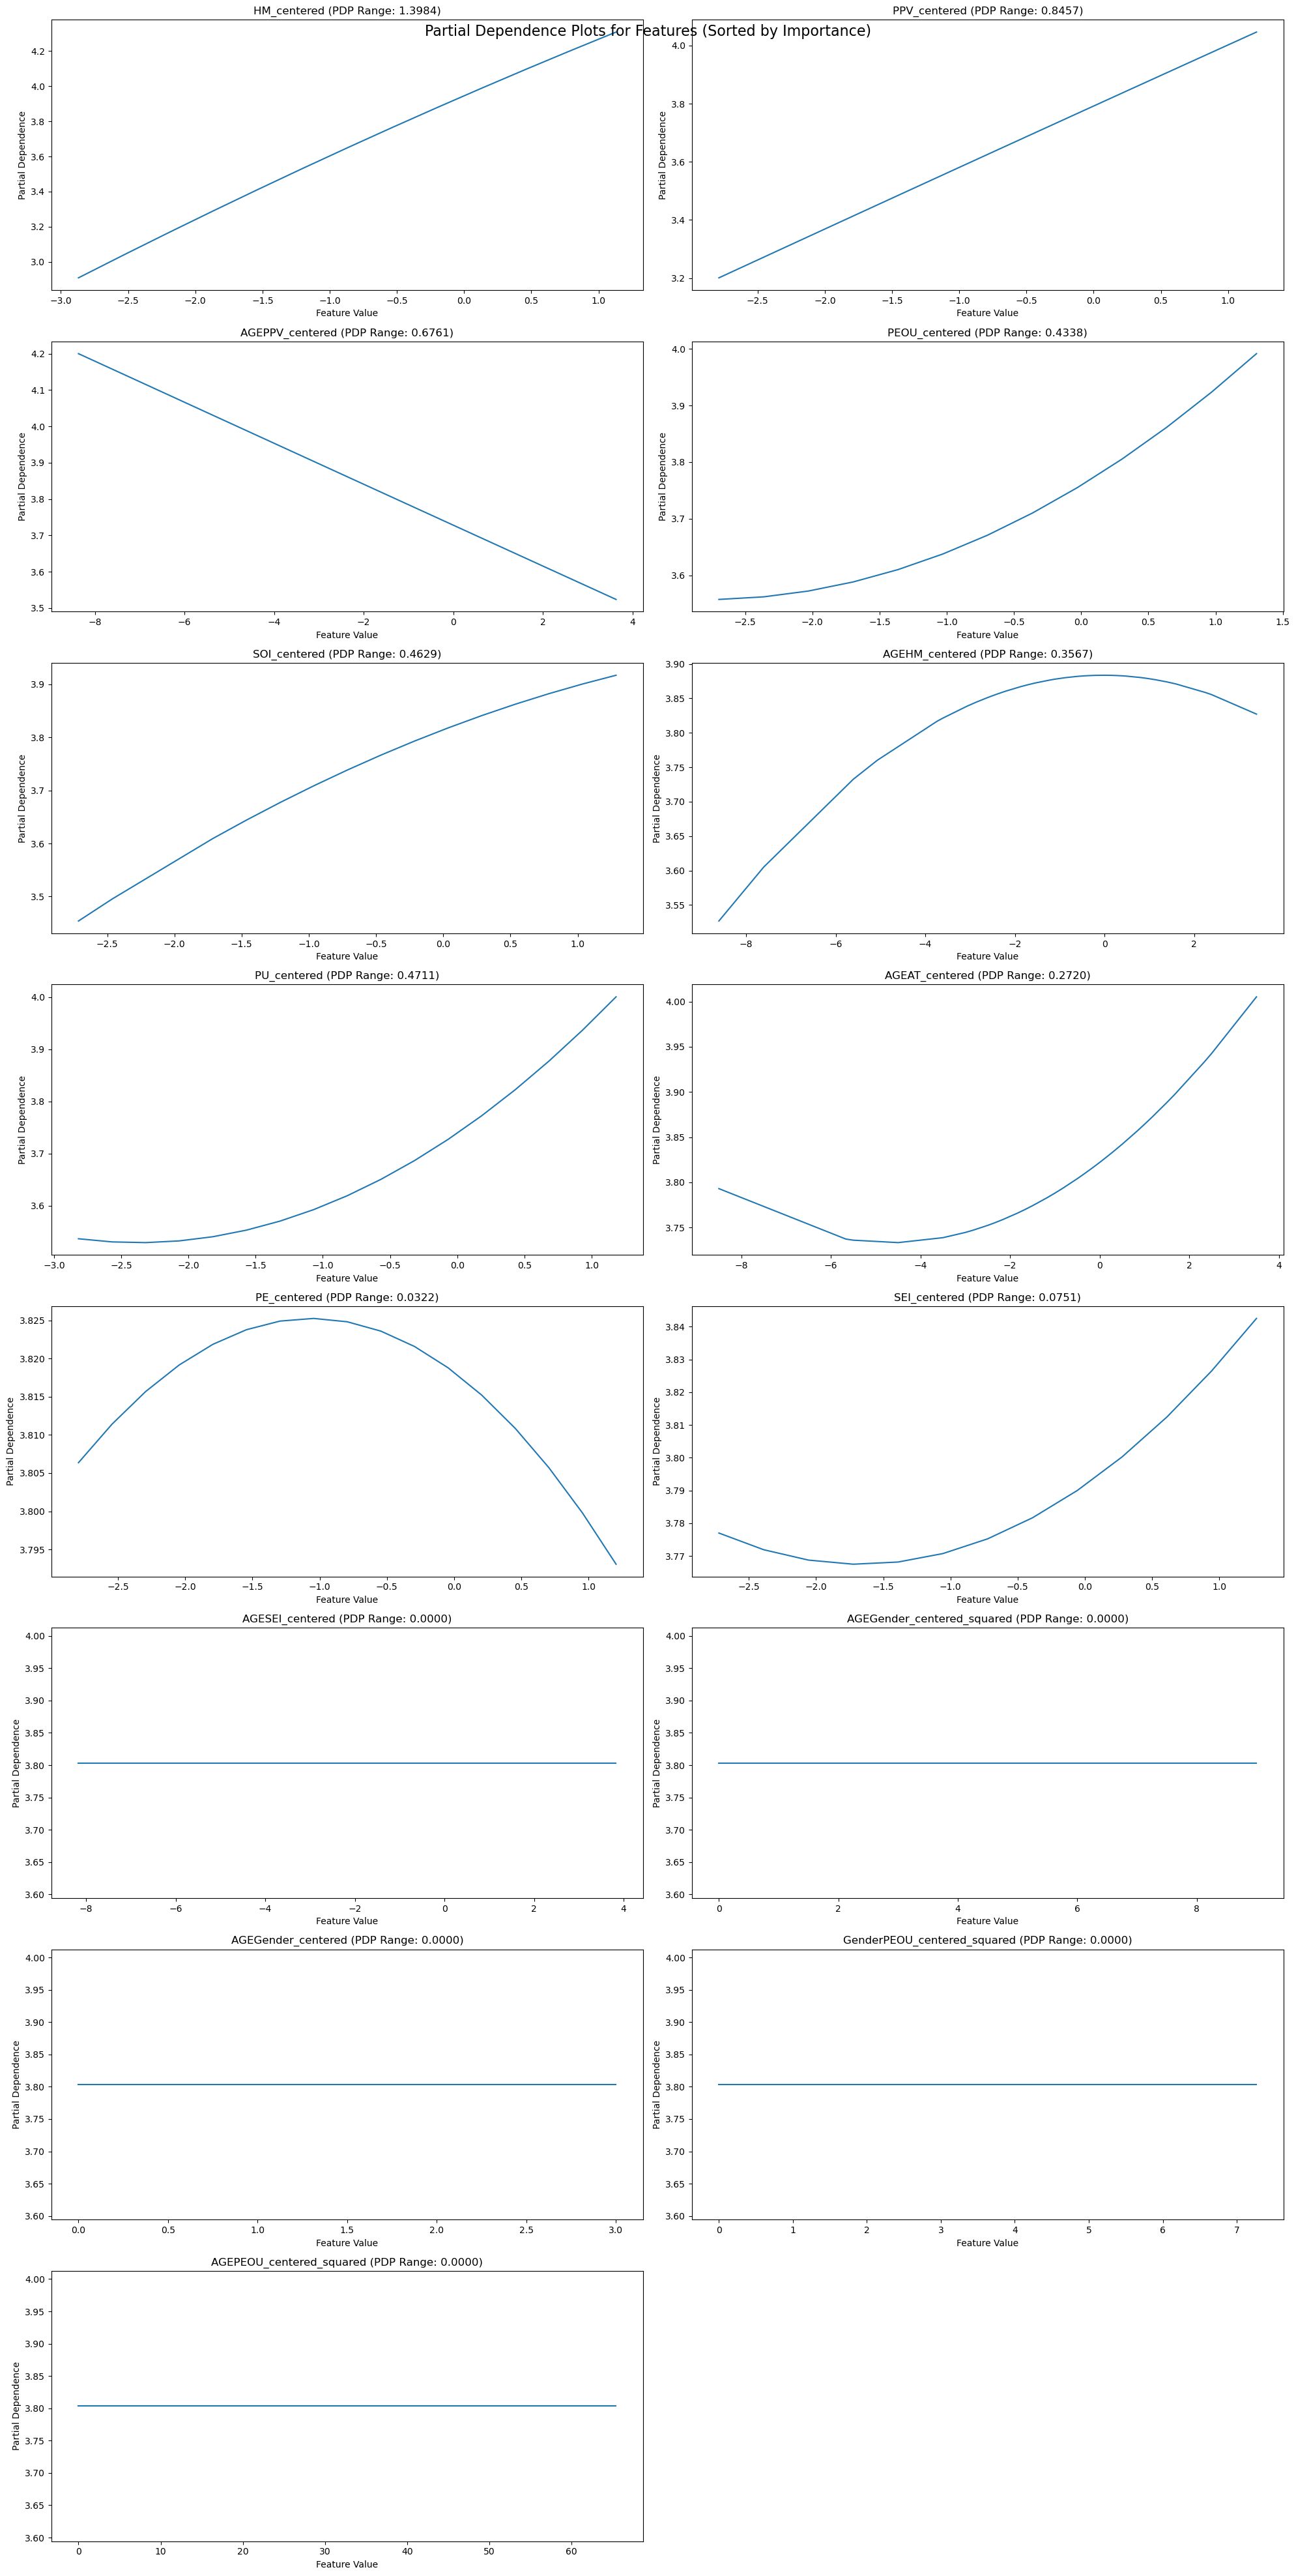


SVR 3 Feature analysis results saved to: svr_3_feature_analysis_results_svr.json

SVR 3 Feature Importance, MUI Scores, and PDP Ranges:
   model_name                      feature  importance  mui_score  pdp_range
39        SVR                  HM_centered    0.442456   0.713684   1.398364
40        SVR                 PPV_centered    0.067484   0.639876   0.845678
31        SVR              AGEPPV_centered    0.066057   0.554054   0.676083
9         SVR                PEOU_centered    0.026146   0.547762   0.433778
29        SVR                 SOI_centered    0.025011   0.529324   0.462937
34        SVR               AGEHM_centered    0.022753   0.629431   0.356743
33        SVR                  PU_centered    0.017462   0.662579   0.471123
38        SVR               AGEAT_centered    0.009966   0.498049   0.271954
25        SVR                  PE_centered    0.007601   0.507603   0.032194
36        SVR                 SEI_centered    0.002835   0.541196   0.075058
37        SVR   

<Figure size 1500x1000 with 0 Axes>

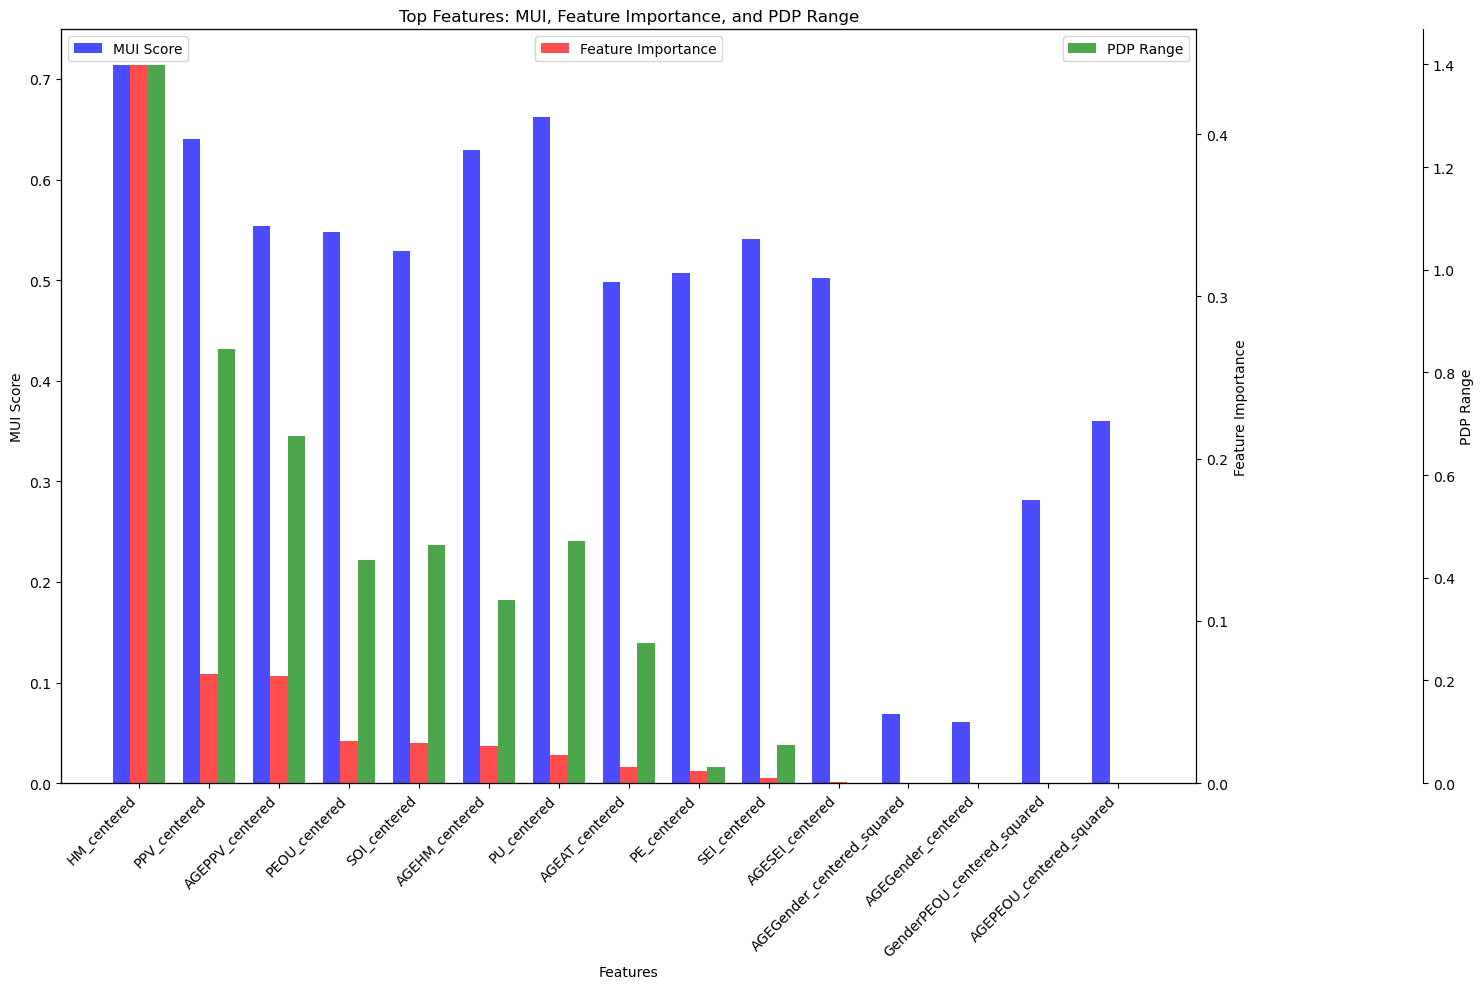

Combined plot of MUI, Feature Importance, and PDP Range has been saved.
Combined top features: ['HM_centered', 'HMAT_centered_squared', 'HMPU_centered', 'HM_centered_squared', 'PU_centered', 'HMPU_centered_squared', 'HMAT_centered', 'PPV_centered', 'AGEHM_centered', 'HMSEI_centered', 'HMPE_centered', 'HMSEI_centered_squared', 'PU_centered_squared', 'HMPEOU_centered', 'PPV_centered_squared', 'AGEPPV_centered', 'SOI_centered', 'PEOU_centered', 'AGEAT_centered', 'SEI_centered', 'PE_centered', 'AGESEI_centered', 'AGEGender_centered_squared', 'AGEGender_centered', 'GenderPEOU_centered_squared', 'AGEPEOU_centered_squared']
An unexpected error occurred: name 'svr_3_top_combined_features' is not defined
Successfully saved SVR best parameters to C:\Users\cemcd\Documents\AR VTO Dissertation\AR VTO Dissertation Oct 6\AR VTO Latest Version Oct16 using PCA as Input\SVR_3_best_params.json

Verification - Loaded parameters:
{
  "model__C": 0.2918265831147537,
  "model__coef0": 1,
  "model__degree": 2

In [72]:
print('3. SVR Model using PCA Feature List - Perform Random Grid Search')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, train_test_split, KFold, RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.inspection import partial_dependence, permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import uniform, loguniform
from sklearn.feature_selection import SelectKBest, f_regression
import json

# Open and read the JSON file
try:
    with open('PCA_selected_features.json', 'r') as json_file:
        feature_data = json.load(json_file)

    # Extract the list of selected features
    pca_selected_features = feature_data['PCA_selected_features']

    print("Type of pca_selected_features:", type(pca_selected_features))
    print("First few items in pca_selected_features:")
    for item in pca_selected_features[:5]:
        print(f"  {item} (type: {type(item)})")

    # If pca_selected_features is a list of strings, use this:
    selected_features = list(dict.fromkeys(pca_selected_features))

    print(f"\nSuccessfully loaded {len(selected_features)} unique PCA selected features.")
    print("\nFirst 5 features:")
    for feature in selected_features[:5]:
        print(f"- {feature}")

    print(f"\nLast 5 features:")
    for feature in selected_features[-5:]:
        print(f"- {feature}")

    print(f"\nNumber of unique features: {len(selected_features)}")

except FileNotFoundError:
    print("Error: The file 'PCA_selected_features.json' was not found.")
except json.JSONDecodeError:
    print("Error: There was a problem decoding the JSON file.")
except KeyError:
    print("Error: The key 'PCA_selected_features' was not found in the JSON file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    
# Select the first 30 features from feature_vars
#feature_vars = selected_features[:30]

feature_vars = selected_features

print(f"Number of features selected: {len(feature_vars)}")
print("Selected features:")
print(feature_vars)

# AGE and Gender are both numerical categorical features, check to see if AGE_num_1, 2,3 and Gender_num_1 are in the PCA list but not in df_survey_cleaned
missing_columns = [col for col in feature_vars if col not in df_survey_cleaned.columns]
print("Missing columns:", missing_columns)

# First, check if 'AGE' and 'Gender' columns exist
if 'AGE_num' in df_survey_cleaned.columns:
    # Create age dummy variables
    df_survey_cleaned['AGE_num_1'] = (df_survey_cleaned['AGE_num'] == 1).astype(int)
    df_survey_cleaned['AGE_num_2'] = (df_survey_cleaned['AGE_num'] == 2).astype(int)
    df_survey_cleaned['AGE_num_3'] = (df_survey_cleaned['AGE_num'] == 3).astype(int)

if 'Gender_num' in df_survey_cleaned.columns:
    # Create age dummy variables
    df_survey_cleaned['Gender_num_1'] = (df_survey_cleaned['Gender_num'] == 1).astype(int)

for col in feature_vars:
    if df_survey_cleaned[col].dtype == 'object':
        if df_survey_cleaned[col].nunique() == 2:
            # Binary variable
            df_survey_cleaned[col] = pd.get_dummies(df_survey_cleaned[col], drop_first=True)
        else:
            # Categorical variable
            dummies = pd.get_dummies(df_survey_cleaned[col], prefix=col, drop_first=True)
            df_survey_cleaned = pd.concat([df_survey_cleaned, dummies], axis=1)
            feature_vars.extend(dummies.columns)
            feature_vars.remove(col)

# Convert boolean columns to int
bool_columns = df_survey_cleaned[feature_vars].select_dtypes(include=['bool']).columns
df_survey_cleaned[bool_columns] = df_survey_cleaned[bool_columns].astype(int)

# Ensure all features are numeric
feature_vars = [col for col in feature_vars if df_survey_cleaned[col].dtype in ['int64', 'float64']]

print("Updated feature variables:", feature_vars)
print(df_survey_cleaned[feature_vars].dtypes)


X = df_survey_cleaned[feature_vars]
y = df_survey_cleaned['BI']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Separate numeric and categorical features
numeric_features = [col for col in feature_vars if col not in ['AGE_num', 'Gender_num']]
categorical_features = ['AGE_num']

# Assuming you have defined numeric_features and categorical_features

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
       #, ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Define the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression)),
    ('model', SVR())
])

from scipy.stats import loguniform, uniform
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'model__kernel': ['rbf', 'poly'],  # Keep both, but prioritize 'rbf'
    'model__C': loguniform(0.1, 100),  # Log-uniform distribution between 0.1 and 100
    'model__gamma': ['scale', 'auto'] + list(loguniform(0.001, 0.1).rvs(3)),  # 'scale', 'auto', and 3 log-uniform samples
    'model__epsilon': uniform(0.01, 0.09).rvs(2)  # 2 uniform samples between 0.01 and 0.1
}

# For polynomial kernel only
poly_params = {
    'model__degree': [2, 3],
    'model__coef0': [0, 1]
}

# Combine the distributions
param_distributions.update({k: v for k, v in poly_params.items() if 'poly' in param_distributions['model__kernel']})

# Set up the RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=100,  # Number of parameter settings that are sampled
    cv=5,  # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Use all available cores
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

# Get the best model
best_model = random_search.best_estimator_

# Perform cross-validation with MUI and feature importance
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = []
feature_importance = {feature: [] for feature in feature_vars}
mui_scores = {feature: [] for feature in feature_vars}

for train_index, val_index in kf.split(X_train):
    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # Fit the entire pipeline
    best_model.fit(X_fold_train, y_fold_train)
    
    # Get the preprocessed data
    X_fold_train_preprocessed = best_model.named_steps['preprocessor'].transform(X_fold_train)
    X_fold_val_preprocessed = best_model.named_steps['preprocessor'].transform(X_fold_val)
    
    # Calculate MUI scores
    mui_fold_scores = mutual_info_regression(X_fold_train_preprocessed, y_fold_train)
    
    # Get feature names after preprocessing
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
    
    # Map MUI scores to original feature names
    for i, feature in enumerate(feature_names):
        original_feature = feature.split('__')[-1]  # Get the original feature name
        if original_feature in mui_scores:
            mui_scores[original_feature].append(mui_fold_scores[i])
    
    # Calculate feature importance (using permutation importance for SVR)
    perm_importance = permutation_importance(best_model, X_fold_val, y_fold_val, n_repeats=10, random_state=42)
    
    # Map feature importances to original feature names
    for i, feature in enumerate(feature_names):
        original_feature = feature.split('__')[-1]  # Get the original feature name
        if original_feature in feature_importance:
            feature_importance[original_feature].append(perm_importance.importances_mean[i])
    
    # Make predictions and calculate scores
    y_pred = best_model.predict(X_fold_val)
    mse = mean_squared_error(y_fold_val, y_pred)
    r2 = r2_score(y_fold_val, y_pred)
    
    cv_scores.append({'MSE': mse, 'R2': r2})

# Calculate average scores
avg_mse = np.mean([score['MSE'] for score in cv_scores])
avg_r2 = np.mean([score['R2'] for score in cv_scores])

print(f"Average MSE: {avg_mse}")
print(f"Average R2: {avg_r2}")

# Extract scores from cv_results
train_mse = -cv_results['train_neg_mean_squared_error']
train_r2 = cv_results['train_r2']
test_mse = -cv_results['test_neg_mean_squared_error']
test_r2 = cv_results['test_r2']


print("SVR 3 Regressor (Best Model) Results (5-fold Cross-Validation):")
print("--------------------------------")
print(f"Training MSE: {train_mse.mean():.4f} (+/- {train_mse.std() * 2:.4f})")
print(f"Training R^2: {train_r2.mean():.4f} (+/- {train_r2.std() * 2:.4f})")
print(f"Testing MSE: {test_mse.mean():.4f} (+/- {test_mse.std() * 2:.4f})")
print(f"Testing R^2: {test_r2.mean():.4f} (+/- {test_r2.std() * 2:.4f})")

# Create model_metrics dataframe
model_metrics = pd.DataFrame({
    'model_name': ['SVR 3 (PCA)'],
    'run_type': ['3rd Run Random Grid Search'],
    'train_mse_mean': [train_mse.mean()],
    'train_mse_std': [train_mse.std()],
    'train_r2_mean': [train_r2.mean()],
    'train_r2_std': [train_r2.std()],
    'test_mse_mean': [test_mse.mean()],
    'test_mse_std': [test_mse.std()],
    'test_r2_mean': [test_r2.mean()],
    'test_r2_std': [test_r2.std()]})


model_metrics.to_csv('svr_3_model_metrics.csv', index=False)
print(f"RF 3 metrics saved to csv: svr_3_model_metrics.csv")

# Calculate average feature importance and MUI scores
avg_feature_importance = {feature: np.mean(scores) for feature, scores in feature_importance.items()}
avg_mui_scores = {feature: np.mean(scores) for feature, scores in mui_scores.items()}

# Sort features by importance
sorted_features = sorted(avg_feature_importance.items(), key=lambda x: x[1], reverse=True)
top_features = [feature for feature, _ in sorted_features[:15]]

# Calculate PDP values for top features
pdp_values = {}
pdp_ranges = {}

for feature in top_features:
    pdp = partial_dependence(best_model, X_train, [feature], kind="average")
    pdp_values[feature] = (pdp["values"][0], pdp["average"][0])
    pdp_ranges[feature] = np.ptp(pdp["average"][0])  # Range of PDP values

##----
# Plot PDP for all features with calculated PDP values (sorted by importance)
features_with_pdp = [feature for feature in top_features if feature in pdp_values]
n_features = len(features_with_pdp)
n_rows = (n_features + 1) // 2  # Calculate the number of rows needed
fig, axes = plt.subplots(n_rows, 2, figsize=(20, 5 * n_rows))
fig.suptitle("Partial Dependence Plots for Features (Sorted by Importance)", fontsize=16)

for i, feature in enumerate(features_with_pdp):
    row = i // 2
    col = i % 2
    ax = axes[row, col] if n_rows > 1 else axes[col]
    x, y = pdp_values[feature]
    ax.plot(x, y)
    ax.set_title(f"{feature} (PDP Range: {pdp_ranges[feature]:.4f})")
    ax.set_xlabel("Feature Value")
    ax.set_ylabel("Partial Dependence")

# Remove any unused subplots
if n_features % 2 != 0:
    fig.delaxes(axes[n_rows-1, 1])

plt.tight_layout()
plt.show()
plt.savefig('svr_3_best_model_pdp_plots_sorted.png', dpi=300, bbox_inches='tight')
plt.close()
##---

# Create results dictionary
results = {
    'top_features': top_features,
    'feature_importance': {feature: avg_feature_importance[feature] for feature in top_features},
    'mui_scores': {feature: avg_mui_scores[feature] for feature in top_features},
    'pdp_values': {feature: pdp_values[feature][1].tolist() for feature in top_features},
    'pdp_feature_values': {feature: pdp_values[feature][0].tolist() for feature in top_features}
}

# Save results to JSON file
with open('SVR 3 feature_analysis_results_svr.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nSVR 3 Feature analysis results saved to: svr_3_feature_analysis_results_svr.json")

# Create svr_important_features dataframe
svr_important_features = pd.DataFrame([
    {'feature': feature, 'importance': avg_feature_importance[feature], 
     'mui_score': avg_mui_scores[feature], 'pdp_range': pdp_ranges.get(feature, np.nan)}
    for feature in feature_vars
])
svr_3_important_features = svr_important_features.sort_values('importance', ascending=False)
svr_3_important_features.insert(0, 'model_name', 'SVR')

print("\nSVR 3 Feature Importance, MUI Scores, and PDP Ranges:")
print(svr_3_important_features)

# Save dataframe to CSV file
svr_3_important_features.to_csv('svr_3_important_features.csv', index=False)
print("\nSVR 3 Feature importance dataframe saved to: svr_3_important_features.csv")

# Evaluate the model on the training set
y_train_pred = best_model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
print("\nTraining set evaluation:")
print(f"Training set MSE: {train_mse:.4f}")
print(f"Training set R2: {train_r2:.4f}")

# Evaluate the model on the test set
y_test_pred = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print("\nTest set evaluation:")
print(f"Test set MSE: {test_mse:.4f}")
print(f"Test set R2: {test_r2:.4f}")

# Calculate and print the difference between training and test performance
mse_difference = train_mse - test_mse
r2_difference = train_r2 - test_r2
print("\nDifference between training and test performance:")
print(f"MSE difference (train - test): {mse_difference:.4f}")
print(f"R2 difference (train - test): {r2_difference:.4f}")

# Create a combined bar plot for MUI, Feature Importance, and PDP Range
plt.figure(figsize=(15, 10))
x = range(len(top_features))
width = 0.25

fig, ax1 = plt.subplots(figsize=(15, 10))
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# Offset the right spine of ax3 by 60 points
ax3.spines['right'].set_position(('axes', 1.2))

rects1 = ax1.bar([i - width for i in x], [avg_mui_scores[f] for f in top_features], width, label='MUI Score', color='b', alpha=0.7)
rects2 = ax2.bar(x, [avg_feature_importance[f] for f in top_features], width, label='Feature Importance', color='r', alpha=0.7)
rects3 = ax3.bar([i + width for i in x], [pdp_ranges[f] for f in top_features], width, label='PDP Range', color='g', alpha=0.7)

ax1.set_xlabel('Features')
ax1.set_ylabel('MUI Score')
ax2.set_ylabel('Feature Importance')
ax3.set_ylabel('PDP Range')
ax1.set_title('Top Features: MUI, Feature Importance, and PDP Range')
ax1.set_xticks(x)
ax1.set_xticklabels(top_features, rotation=45, ha='right')

ax1.legend(loc='upper left')
ax2.legend(loc='upper center')
ax3.legend(loc='upper right')

fig.tight_layout()
plt.show()
plt.savefig('svr_top_features_mui_importance_pdp.png', dpi=300, bbox_inches='tight')
plt.close()

print("Combined plot of MUI, Feature Importance, and PDP Range has been saved.")

# Get top 15 features based on MUI scores
mui_top_15 = sorted(avg_mui_scores.items(), key=lambda x: x[1], reverse=True)[:15]
mui_top_15_names = [feature for feature, _ in mui_top_15]

# Get top 15 features based on PDP ranges
pdp_top_15 = sorted(pdp_ranges.items(), key=lambda x: x[1], reverse=True)[:15]
pdp_top_15_names = [feature for feature, _ in pdp_top_15]

# Get top 15 features based on feature importance
importance_top_15 = sorted(avg_feature_importance.items(), key=lambda x: x[1], reverse=True)[:15]
importance_top_15_names = [feature for feature, _ in importance_top_15]

# Combine all top features and remove duplicates while preserving order
all_top_features = mui_top_15_names + pdp_top_15_names + importance_top_15_names
#top_15_feature_names = list(dict.fromkeys(all_top_features))[:15]
svr_3_top_feature_names = list(dict.fromkeys(all_top_features))

print(f"Combined top features: {svr_3_top_feature_names}")

import os
import json

# Define the file name
file_name = 'svr_3_top_combined_features.json'

# Get the current directory
current_directory = os.getcwd()

# Create the full file path
file_path = os.path.join(current_directory, file_name)

# Save the top 15 important features to a JSON file
try:
    with open(file_path, 'w') as f:
        json.dump(svr_3_top_combined_features, f, indent=2)
    print(f"Successfully saved SVR 3 combined features to {file_name}")
except IOError as e:
    print(f"An error occurred while writing to the file: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


# Convert NumPy types to Python types
def convert_numpy_types(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

SVR_3_best_params = {k: convert_numpy_types(v) for k, v in random_search.best_params_.items()}

import os
import json

# Define the best parameters' file name
SVR_3_best_params_file_name = 'SVR_3_best_params.json'

# Get the current directory path
current_directory = os.getcwd()

# Create the full file path in the current directory
SVR_3_best_params_file_path = os.path.join(current_directory, SVR_3_best_params_file_name)

# Save the best parameters to a JSON file
try:
    with open(SVR_3_best_params_file_path, 'w') as f:
        json.dump(SVR_3_best_params, f, indent=2)
    print(f"Successfully saved SVR best parameters to {SVR_3_best_params_file_path}")
except IOError as e:
    print(f"An error occurred while writing to the file: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# Verify the saved data by reading it back
try:
    with open(SVR_3_best_params_file_path, 'r') as f:
        loaded_params = json.load(f)
    print("\nVerification - Loaded parameters:")
    print(json.dumps(loaded_params, indent=2))
except Exception as e:
    print(f"An error occurred while verifying the saved file: {e}")

print('End of Script 3')

## 4. SVR Using PCA as Feature List - Grid Search 

Script 4
Successfully loaded 64 unique PCA selected features.
PCA Feaute: ['AGEGender_centered_squared', 'AGEGender_centered', 'GenderPEOU_centered_squared', 'AGEPEOU_centered_squared', 'GenderPEOU_centered', 'AGESOI_centered_squared', 'AGESEI_centered_squared', 'PEOU_centered_squared', 'AGEPEOU_centered', 'PEOU_centered', 'AGEPPV_centered_squared', 'GenderAT_centered', 'GenderSEI_centered', 'AGEHM_centered_squared', 'GenderPU_centered', 'GenderHM_centered', 'AGEPU_centered_squared', 'GenderAT_centered_squared', 'GenderPE_centered', 'GenderPE_centered_squared', 'GenderSEI_centered_squared', 'GenderPPV_centered', 'GenderSOI_centered', 'GenderSOI_centered_squared', 'GenderPPV_centered_squared', 'PE_centered', 'GenderHM_centered_squared', 'AGEPE_centered', 'AGESOI_centered', 'SOI_centered', 'GenderPU_centered_squared', 'AGEPPV_centered', 'AGEPU_centered', 'PU_centered', 'AGEHM_centered', 'SOI_centered_squared', 'SEI_centered', 'AGESEI_centered', 'AGEAT_centered', 'HM_centered', 'PPV_cente

<Figure size 1500x1000 with 0 Axes>

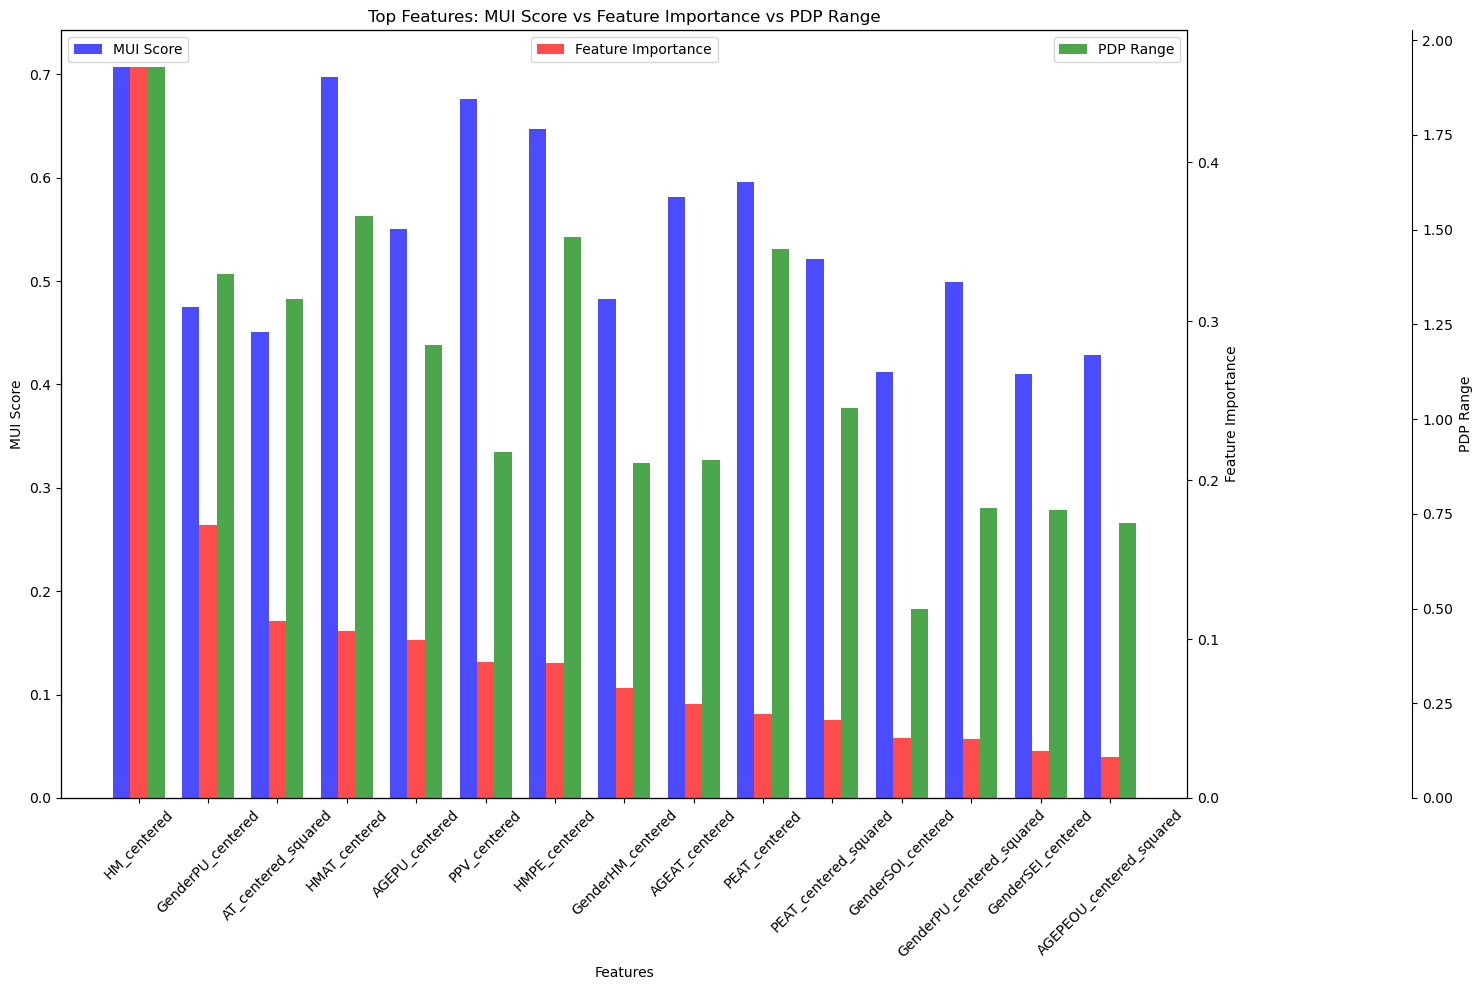

Deduplicated top features saved to SVR_4_top_features.json
Script 4 execution completed successfully.


In [73]:
print('Script 4')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, train_test_split, KFold, GridSearchCV
from sklearn.svm import SVR  # Changed from ElasticNet to SVR
from sklearn.inspection import partial_dependence
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error, r2_score
import json
import os

# Load PCA selected features
try:
    with open('PCA_selected_features.json', 'r') as json_file:
        feature_data = json.load(json_file)
    selected_features = list(dict.fromkeys(feature_data['PCA_selected_features']))
    print(f"Successfully loaded {len(selected_features)} unique PCA selected features.")
except Exception as e:
    print(f"An error occurred while loading PCA selected features: {e}")
    selected_features = []

feature_vars = selected_features

# Data preprocessing (assuming df_survey_cleaned is already loaded)
if 'AGE_num' in df_survey_cleaned.columns:
    df_survey_cleaned['AGE_num_1'] = (df_survey_cleaned['AGE_num'] == 1).astype(int)
    df_survey_cleaned['AGE_num_2'] = (df_survey_cleaned['AGE_num'] == 2).astype(int)
    df_survey_cleaned['AGE_num_3'] = (df_survey_cleaned['AGE_num'] == 3).astype(int)

if 'Gender_num' in df_survey_cleaned.columns:
    df_survey_cleaned['Gender_num_1'] = (df_survey_cleaned['Gender_num'] == 1).astype(int)

for col in feature_vars:
    if df_survey_cleaned[col].dtype == 'object':
        if df_survey_cleaned[col].nunique() == 2:
            df_survey_cleaned[col] = pd.get_dummies(df_survey_cleaned[col], drop_first=True)
        else:
            dummies = pd.get_dummies(df_survey_cleaned[col], prefix=col, drop_first=True)
            df_survey_cleaned = pd.concat([df_survey_cleaned, dummies], axis=1)
            feature_vars.extend(dummies.columns)
            feature_vars.remove(col)

bool_columns = df_survey_cleaned[feature_vars].select_dtypes(include=['bool']).columns
df_survey_cleaned[bool_columns] = df_survey_cleaned[bool_columns].astype(int)

feature_vars = [col for col in feature_vars if df_survey_cleaned[col].dtype in ['int64', 'float64']]

print(f"PCA Feaute: {feature_vars}")

X = df_survey_cleaned[feature_vars]
y = df_survey_cleaned['BI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = [col for col in feature_vars if col not in ['AGE_num', 'Gender_num']]
categorical_features = ['AGE_num', 'Gender_num']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ])

# Create a pipeline with the preprocessor and SVR model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVR())  # Changed from ElasticNet to SVR
])

# Define parameter grid for SVR hyperparameters
param_grid = {
    'model__kernel': ['linear', 'poly', 'rbf'],  # Added different kernels for SVR
    'model__C': [0.1, 1],
    'model__gamma': ['scale', 'auto'],  # Gamma options for SVR
    'model__degree': [2, 3],  # Degree for polynomial kernel only
    'model__epsilon': [0.01, 0.1, 1]  # Epsilon parameter for SVR
}

# Perform grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Best parameters:", best_params)

# Save best parameters to JSON file
current_directory = os.getcwd()
file_name = 'SVR_4_best_parameters.json'
file_path = os.path.join(current_directory, file_name)

with open(file_path, 'w') as f:
    json.dump(best_params, f, indent=4)

print(f"Best parameters saved to: {file_path}")

# Perform cross-validation on the best model
cv_results = cross_validate(best_model, X_train, y_train, cv=5,
                            scoring=('neg_mean_squared_error', 'r2'),
                            return_train_score=True)

# Calculate mean and std of the scores
train_mse = -cv_results['train_neg_mean_squared_error']
test_mse = -cv_results['test_neg_mean_squared_error']
train_r2 = cv_results['train_r2']
test_r2 = cv_results['test_r2']

print("SVR (Best Model) Results (5-fold Cross-Validation):")
print("--------------------------------")
print(f"Training MSE: {train_mse.mean():.4f} (+/- {train_mse.std() * 2:.4f})")
print(f"Training R^2: {train_r2.mean():.4f} (+/- {train_r2.std() * 2:.4f})")
print(f"Testing MSE: {test_mse.mean():.4f} (+/- {test_mse.std() * 2:.4f})")
print(f"Testing R^2: {test_r2.mean():.4f} (+/- {test_r2.std() * 2:.4f})")

# Create model_metrics dataframe
model_metrics = pd.DataFrame({
    'model_name': ['SVR (PCA)'],
    'run_type': ['Grid Search'],
    'train_mse_mean': [train_mse.mean()],
    'train_mse_std': [train_mse.std()],
    'train_r2_mean': [train_r2.mean()],
    'train_r2_std': [train_r2.std()],
    'test_mse_mean': [test_mse.mean()],
    'test_mse_std': [test_mse.std()],
    'test_r2_mean': [test_r2.mean()],
    'test_r2_std': [test_r2.std()]
})

# Save model_metrics to CSV
model_metrics.to_csv('SVR_4_model_metrics.csv', index=False)
print("Model metrics saved to: SVR_model_metrics.csv")

# Feature importance and MUI scores calculations using the best model
X_preprocessed = best_model.named_steps['preprocessor'].transform(X)
mui_scores = dict(zip(feature_vars, mutual_info_regression(X_preprocessed, y)))

# Since SVR does not provide coefficients like ElasticNet,
# we can use permutation importance instead.
from sklearn.inspection import permutation_importance

perm_importance_result = permutation_importance(best_model, X_test, y_test,
                                                n_repeats=30,
                                                random_state=42,
                                                n_jobs=-1)

feature_importance = {feature: perm_importance_result.importances_mean[i] 
                      for i, feature in enumerate(feature_vars)}

# Sort features by importance
sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)
top_features = [feature for feature, _ in sorted_features[:15]]

# Calculate PDP values for top features using partial dependence plots
pdp_values = {}
pdp_ranges = {}

for feature in top_features:
    pdp_result = partial_dependence(best_model, X_train, [feature], kind="average")
    pdp_values[feature] = (pdp_result["values"][0], pdp_result["average"][0])
    pdp_ranges[feature] = np.ptp(pdp_result["average"][0])

# Create results dictionary and save to JSON
results = {
    'top_features': top_features,
    'feature_importance': {feature: feature_importance[feature] for feature in top_features},
    'mui_scores': {feature: mui_scores[feature] for feature in top_features},
    'pdp_values': {feature: pdp_values[feature][1].tolist() for feature in top_features},
    'pdp_feature_values': {feature: pdp_values[feature][0].tolist() for feature in top_features}
}

with open('SVR_4_feature_analysis_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Create and save important features dataframe for SVR model
SVR_important_features = pd.DataFrame([
    {'feature': feature,
     'importance': feature_importance[feature],
     'mui_score': mui_scores[feature],
     'pdp_range': pdp_ranges.get(feature, np.nan)}
     for feature in feature_vars
])
SVR_important_features.sort_values('importance', ascending=False).to_csv('SVR_4_important_features.csv', index=False)
top_features_importance = [feature for feature, _ in sorted_features[:15]]

# Create combined bar plot for MUI scores and Feature Importance using matplotlib
plt.figure(figsize=(15, 10))
x = range(len(top_features))
width = 0.25

fig, ax1 = plt.subplots(figsize=(15, 10))
ax2 = ax1.twinx()
ax3 = ax1.twinx()

ax3.spines['right'].set_position(('axes', 1.2))

rects1 = ax1.bar([i - width for i in x], [mui_scores[f] for f in top_features], width,
                  label='MUI Score', color='b', alpha=0.7)
rects2 = ax2.bar(x, [feature_importance[f] for f in top_features], width,
                  label='Feature Importance', color='r', alpha=0.7)
rects3 = ax3.bar([i + width for i in x], [pdp_ranges[f] for f in top_features], width,
                  label='PDP Range', color='g', alpha=0.7)

ax1.set_xlabel('Features')
ax1.set_ylabel('MUI Score')
ax2.set_ylabel('Feature Importance')
ax3.set_ylabel('PDP Range')
ax1.set_title('Top Features: MUI Score vs Feature Importance vs PDP Range')
ax1.set_xticks(x)
ax1.set_xticklabels(top_features, rotation=45)

ax1.legend(loc='upper left')
ax2.legend(loc='upper center')
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()
plt.savefig('SVR_top_features_mui_importance_pdp.png', dpi=300)
plt.close() 

# Create lists of top features from each category
top_features_mui = sorted(mui_scores.items(), key=lambda x: x[1], reverse=True)[:15]
top_features_mui_list = [feature for feature, _ in top_features_mui]

top_features_pdp = list(pdp_ranges.keys())[:15]  # Assuming you want the first 15 features with PDP ranges

# Step 6: Combine and deduplicate all feature lists
combined_features = set(top_features_importance + top_features_mui_list + top_features_pdp)

# Step 7: Convert to a list for JSON serialization
deduped_feature_list = list(combined_features)

# Step 8: Write the deduplicated list to a JSON file
json_file_name = 'SVR_4_top_features.json'
with open(json_file_name, 'w') as json_file:
    json.dump(deduped_feature_list, json_file, indent=4)


print(f"Deduplicated top features saved to {json_file_name}")


print("Script 4 execution completed successfully.")

# 5. Final SVR Model

5. Final Model with Cross-Validation
Best parameters loaded successfully:
{
  "model__C": 0.1,
  "model__degree": 2,
  "model__epsilon": 0.01,
  "model__gamma": "scale",
  "model__kernel": "linear"
}
SVR features loaded successfully.
Number of features loaded: 27
Top features: ['AGEAT_centered', 'HMSOI_centered', 'HMSEI_centered', 'PEAT_centered', 'GenderPU_centered', 'PU_centered', 'PPV_centered_squared', 'HMPU_centered_squared', 'AGEHM_centered', 'GenderSOI_centered', 'GenderPU_centered_squared', 'AGEPU_centered', 'HMAT_centered_squared', 'HM_centered', 'HMAT_centered']

Cross-Validation Results:
------------------------
Mean MSE: 0.1633 (+/- 0.0561)
Mean R²: 0.7389 (+/- 0.2341)

Final Model Performance (on entire dataset):
------------------------
MSE: 0.1519
R²: 0.8005
Support Vector Regressor (Best Model) Results (5-fold Cross-Validation):
--------------------------------
Training MSE: 0.1496 (+/- 0.0145)
Training R^2: 0.8022 (+/- 0.0291)
Testing MSE: 0.1633 (+/- 0.0561)
Testing R

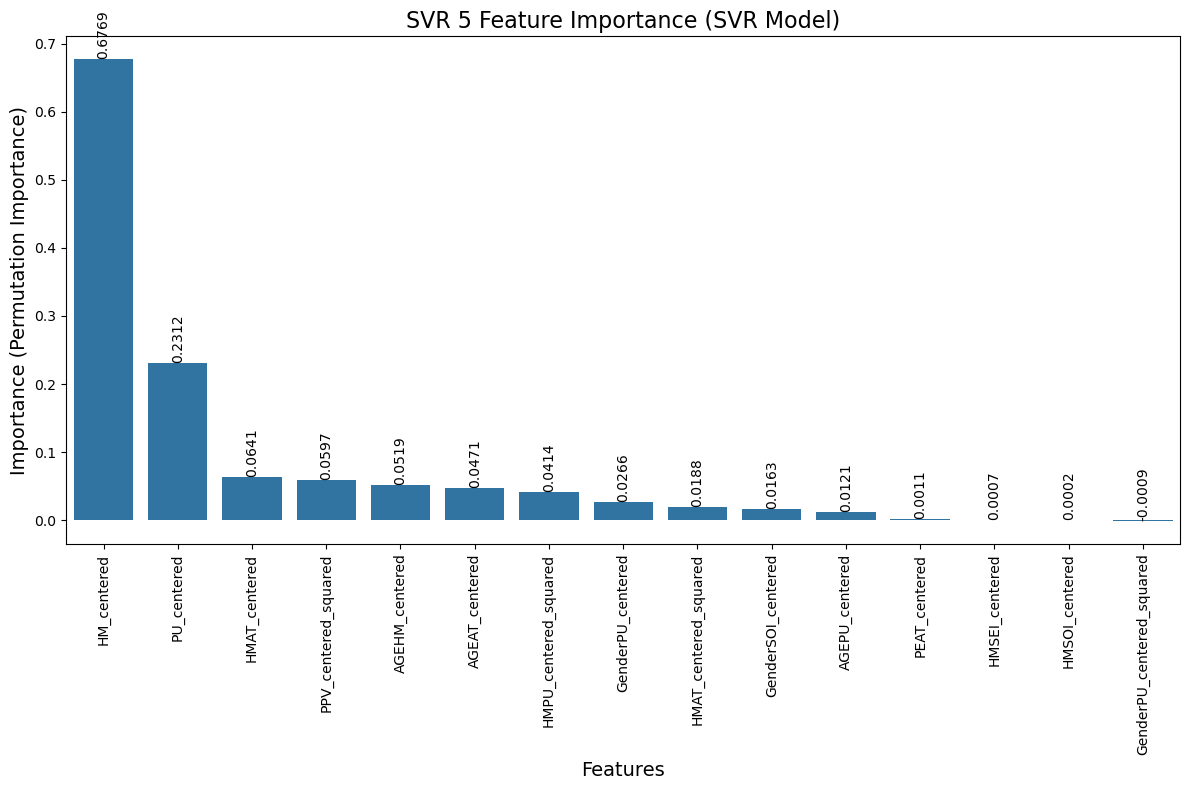


SVR 5 Feature importances saved to svr_5_feature_importances_cv.json

SVR 5 Performance metrics saved to svr_5_performance_metrics_cv.json


In [74]:
 print(f"5. Final Model with Cross-Validation")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import os
import json

# Define the file name
file_name = 'svr_4_best_parameters.json'

# Get the current directory
current_directory = os.getcwd()

# Create the full file path
file_path = os.path.join(current_directory, file_name)

# Load the best parameters from the JSON file
try:
    with open(file_path, 'r') as f:
        best_params = json.load(f)
    print("Best parameters loaded successfully:")
    print(json.dumps(best_params, indent=2))
except FileNotFoundError:
    print(f"File not found: {file_name}")
    best_params = {}
    print("Using default parameters for SVR")
except json.JSONDecodeError:
    print(f"Error decoding JSON from file: {file_name}")
    best_params = {}
    print("Using default parameters for SVR")
except Exception as e:
    print(f"An unexpected error occurred while reading the file: {str(e)}")
    best_params = {}
    print("Using default parameters for SVR")


# Define the file name
file_name = 'SVR_4_top_features.json'

# Get the current directory
current_directory = os.getcwd()

# Create the full file path
file_path = os.path.join(current_directory, file_name)

# Load the selected features from the JSON file
try:
    with open(file_path, 'r') as f:
        features_to_keep = json.load(f)
    print("SVR features loaded successfully.")
    print(f"Number of features loaded: {len(features_to_keep)}")
except FileNotFoundError:
    print(f"File not found: {file_name}")
    features_to_keep = []
except json.JSONDecodeError:
    print(f"Error decoding JSON from file: {file_name}")
    features_to_keep = []
except Exception as e:
    print(f"An unexpected error occurred while reading the file: {str(e)}")
    features_to_keep = []

# use features_to_keep in your code

top_features = features_to_keep[:15]
print("Top features:", top_features)

# Get features
X = df_survey_cleaned[top_features]
y = df_survey_cleaned['BI']

# Separate numeric and categorical features
numeric_features = [col for col in top_features if col != 'AGE_num']
categorical_features = ['AGE_num']

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
        #,('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Remove the 'model__' prefix from the parameters
best_params = {k.replace('model__', ''): v for k, v in best_params.items()}

# Create a pipeline with the preprocessor and SVR model
svr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVR(**best_params))
])

# Perform cross-validation
cv_scores_mse = cross_val_score(svr_pipeline, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_r2 = cross_val_score(svr_pipeline, X, y, cv=5, scoring='r2')

# Convert MSE scores to positive values
cv_scores_mse = -cv_scores_mse

# Calculate mean and standard deviation of cross-validation scores
cv_mse_mean = cv_scores_mse.mean()
cv_mse_std = cv_scores_mse.std()
cv_r2_mean = cv_scores_r2.mean()
cv_r2_std = cv_scores_r2.std()

# Print cross-validation results
print("\nCross-Validation Results:")
print("------------------------")
print(f"Mean MSE: {cv_mse_mean:.4f} (+/- {cv_mse_std * 2:.4f})")
print(f"Mean R²: {cv_r2_mean:.4f} (+/- {cv_r2_std * 2:.4f})")

# Fit the model on the entire dataset
svr_pipeline.fit(X, y)

# Make predictions on the entire dataset
y_pred = svr_pipeline.predict(X)

# Calculate performance metrics
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

# Print results
print("\nFinal Model Performance (on entire dataset):")
print("------------------------")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

# Perform cross-validation on the best model
cv_results = cross_validate(svr_pipeline, X, y, cv=5,
                            scoring=('neg_mean_squared_error', 'r2'),
                            return_train_score=True)

# Calculate mean and std of the scores
train_mse = -cv_results['train_neg_mean_squared_error']
test_mse = -cv_results['test_neg_mean_squared_error']
train_r2 = cv_results['train_r2']
test_r2 = cv_results['test_r2']

print("Support Vector Regressor (Best Model) Results (5-fold Cross-Validation):")
print("--------------------------------")
print(f"Training MSE: {train_mse.mean():.4f} (+/- {train_mse.std() * 2:.4f})")
print(f"Training R^2: {train_r2.mean():.4f} (+/- {train_r2.std() * 2:.4f})")
print(f"Testing MSE: {test_mse.mean():.4f} (+/- {test_mse.std() * 2:.4f})")
print(f"Testing R^2: {test_r2.mean():.4f} (+/- {test_r2.std() * 2:.4f})")

# Create model_metrics dataframe
model_metrics = pd.DataFrame({
    'model_name': ['SVR 5 (Final Run)'],
    'run_type': ['5th Run top Features/Best params'],
    'train_mse_mean': [train_mse.mean()],
    'train_mse_std': [train_mse.std()],
    'train_r2_mean': [train_r2.mean()],
    'train_r2_std': [train_r2.std()],
    'test_mse_mean': [test_mse.mean()],
    'test_mse_std': [test_mse.std()],
    'test_r2_mean': [test_r2.mean()],
    'test_r2_std': [test_r2.std()]
})
 
model_metrics.to_csv('svr_5_best_model_metrics.csv', index=False)
print(f"SVR 5 Final model metrics saved to csv: svr_5_best_model_metrics.csv")
print(model_metrics)

# Get feature names after preprocessing
feature_names = svr_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Calculate feature importances using permutation importance
perm_importance = permutation_importance(svr_pipeline, X, y, n_repeats=10, random_state=42)

# Ensure that feature_names and importances have the same length
min_length = min(len(feature_names), len(perm_importance.importances_mean))
feature_names = feature_names[:min_length]
importances = perm_importance.importances_mean[:min_length]

# Create feature importances DataFrame
feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
feature_importances = feature_importances.sort_values('importance', ascending=False)
feature_importances['feature'] = feature_importances['feature'].str.replace('num__', '').str.replace('cat__', '')

print("\nFeature Importances:")
print(feature_importances)

# Plot feature importances

# Sort features by importance in descending order and select top 15
top_15_features = feature_importances.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_15_features, x='feature', y='importance')
plt.title('SVR 5 Feature Importance (SVR Model)', fontsize=16)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Importance (Permutation Importance)', fontsize=14)
plt.xticks(rotation=90)

# Add value labels on top of each bar
for i, v in enumerate(top_15_features['importance']):
    plt.text(i, v, f'{v:.4f}', ha='center', va='bottom', rotation=90)

plt.tight_layout()
plt.savefig('svr_5_feature_importance_cv.png', dpi=300, bbox_inches='tight')
plt.show()

# Save feature importances to JSON
svr_5_feature_importances_json = feature_importances.to_dict(orient='records')
with open('svr_5_feature_importances_cv.json', 'w') as f:
    json.dump(svr_5_feature_importances_json, f, indent=2)

print("\nSVR 5 Feature importances saved to svr_5_feature_importances_cv.json")

# Save model performance metrics to JSON
performance_metrics = {
    'cv_mse_mean': cv_mse_mean,
    'cv_mse_std': cv_mse_std,
    'cv_r2_mean': cv_r2_mean,
    'cv_r2_std': cv_r2_std,
    'final_mse': mse,
    'final_r2': r2
}

with open('svr_5_performance_metrics_cv.json', 'w') as f:
    json.dump(performance_metrics, f, indent=2)

print("\nSVR 5 Performance metrics saved to svr_5_performance_metrics_cv.json")

## Capture all metrics into one file for anlysis

In [75]:
print(f"Capturing all model metrics")

Capturing all model metrics


### Read SVR 1  Best Model Metrics

In [76]:
import os
import pandas as pd

# Define the file name
file_name = 'svr_1_model_metrics.csv'

# Get the current working directory and create the full file path
current_dir = os.getcwd()
file_path = os.path.join(current_dir, file_name)

try:
    # Read the CSV file
    svr_1_best_model_metrics = pd.read_csv(file_path)
    print(f"Successfully read the file: {file_name}")

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in the current directory.")
    svr_1_best_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_name}' is empty.")
    svr_1_best_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except Exception as e:
    print(f"An unexpected error occurred while reading the file: {str(e)}")
    svr_1_best_model_metrics = pd.DataFrame()  # Create an empty DataFramec

Successfully read the file: svr_1_model_metrics.csv


### Read SVR 2  Best Model Metrics

In [77]:
import os
import pandas as pd

# Define the file name
file_name = 'svr_2_model_metrics.csv'

# Get the current working directory and create the full file path
current_dir = os.getcwd()
file_path = os.path.join(current_dir, file_name)

try:
    # Read the CSV file
    svr_2_best_model_metrics = pd.read_csv(file_path)
    print(f"Successfully read the file: {file_name}")

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in the current directory.")
    svr_2_best_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_name}' is empty.")
    svr_2_best_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except Exception as e:
    print(f"An unexpected error occurred while reading the file: {str(e)}")
    svr_2_best_model_metrics = pd.DataFrame()  # Create an empty DataFrame

Successfully read the file: svr_2_model_metrics.csv


### Read SVR 3  Best Model Metrics

In [78]:
import os
import pandas as pd

# Define the file name
file_name = 'svr_3_model_metrics.csv'

# Get the current working directory and create the full file path
current_dir = os.getcwd()
file_path = os.path.join(current_dir, file_name)

try:
    # Read the CSV file
    svr_3_best_model_metrics = pd.read_csv(file_path)
    print(f"Successfully read the file: {file_name}")

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in the current directory.")
    svr_3_best_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_name}' is empty.")
    svr_3_best_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except Exception as e:
    print(f"An unexpected error occurred while reading the file: {str(e)}")
    svr_3_best_model_metrics = pd.DataFrame()  # Create an empty DataFrame

Successfully read the file: svr_3_model_metrics.csv


### Read SVR 4  Best Model Metrics

In [79]:
import os
import pandas as pd

# Define the file name
file_name = 'svr_4_model_metrics.csv'

# Get the current working directory and create the full file path
current_dir = os.getcwd()
file_path = os.path.join(current_dir, file_name)

try:
    # Read the CSV file
    svr_4_best_model_metrics = pd.read_csv(file_path)
    print(f"Successfully read the file: {file_name}")

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in the current directory.")
    svr_4_best_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_name}' is empty.")
    svr_4_best_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except Exception as e:
    print(f"An unexpected error occurred while reading the file: {str(e)}")
    svr_4_best_model_metrics = pd.DataFrame()  # Create an empty DataFrame

Successfully read the file: svr_4_model_metrics.csv


### Read SVR 5  Best Model Metrics

In [80]:
import os
import pandas as pd

# Define the file name
file_name = 'svr_5_best_model_metrics.csv'

# Get the current working directory and create the full file path
current_dir = os.getcwd()
file_path = os.path.join(current_dir, file_name)

try:
    # Read the CSV file
    svr_5_best_model_metrics = pd.read_csv(file_path)
    print(f"Successfully read the file: {file_name}")

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in the current directory.")
    svr_5_best_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_name}' is empty.")
    svr_5_best_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except Exception as e:
    print(f"An unexpected error occurred while reading the file: {str(e)}")
    svr_5_best_model_metrics = pd.DataFrame()  # Create an empty DataFrame

Successfully read the file: svr_5_best_model_metrics.csv


In [81]:
SVR_All_models_metrics_combined = pd.concat([svr_1_best_model_metrics,svr_2_best_model_metrics,svr_3_best_model_metrics,svr_4_best_model_metrics,svr_5_best_model_metrics],axis=0)
 

In [82]:
SVR_All_models_metrics_combined['mse_diff'] = SVR_All_models_metrics_combined['train_mse_mean'] - (SVR_All_models_metrics_combined['test_mse_mean'])

In [83]:
SVR_All_models_metrics_combined['r2_diff'] = SVR_All_models_metrics_combined['train_r2_mean'] - (SVR_All_models_metrics_combined['test_r2_mean'])

In [84]:
SVR_All_models_metrics_combined[['model_name','run_type','train_r2_mean','test_r2_mean','r2_diff','train_mse_mean','test_mse_mean','mse_diff']]

,model_name,run_type,train_r2_mean,test_r2_mean,r2_diff,train_mse_mean,test_mse_mean,mse_diff
0,SVR 1 (TAM ),Initial Run,0.824978,0.738857,0.086121,0.135604,0.195139,-0.059535
0,SVR 2 (PCA),2nd Run,0.806653,0.719410,0.087244,0.149722,0.209186,-0.059464
0,SVR 3 (PCA),3rd Run Random Grid Search,0.806653,0.719410,0.087244,0.149722,0.209186,-0.059464
0,SVR (PCA),Grid Search,0.837352,0.779773,0.057579,0.125934,0.164717,-0.038783
0,SVR 5 (Final Run),5th Run top Features/Best params,0.802170,0.738911,0.063259,0.149559,0.163333,-0.013774


In [85]:
SVR_All_models_metrics_combined.to_csv('SVR_All_models_metrics_combined.csv', index=False)

In [86]:
print('End of SVR Script')

End of SVR Script


In [87]:
from datetime import datetime

# Get the current date and time
current_time = datetime.now()

print(f"Current date and time: {current_time}")

Current date and time: 2024-10-24 15:04:00.592764
